# <font color="steelblue">Máquinas de vector soporte no lineales</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 07/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

**Recomendación**: realizar antes el cuaderno de SVM lineales.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# Análisis discriminante y utilidades
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV, KFold
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
from sklearn.metrics import pairwise_distances

RNG = 42

# SVM y utilidades
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_moons


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.6 MB/s eta 0:00:00


# <font color="steelblue">Introducción</font>

En el cuaderno anterior vimos que la SVM lineal busca un **hiperplano recto** que separe las clases. Funciona muy bien cuando la frontera entre grupos es **aproximadamente recta**, pero fracasa cuando la separación natural es **curva**: por mucho que ajustemos $C$, una recta no puede rodear un grupo ni serpentear entre dos.

La idea genial de las SVM no lineales es **no cambiar el algoritmo, sino el espacio**: si proyectamos los datos a un **espacio de más dimensiones**, una frontera curva en el espacio original puede convertirse en un **hiperplano recto** en el nuevo espacio. Y lo más sorprendente —el llamado **truco del kernel**— es que podemos hacer todo eso **sin calcular nunca esas nuevas dimensiones**, solo cambiando el producto escalar por una función llamada **kernel**.

Este cuaderno hace especial hincapié en **entender los kernels**: qué hacen geométricamente, por qué funcionan y cómo elegirlos. Seguimos centrados en **clasificación** y usaremos las funciones del curso para el preprocesado y la evaluación.

# <font color="steelblue">1. SVM no lineales</font>

Empezamos con **tres juguetes** en dos dimensiones donde la frontera es claramente **no lineal**. El primero —dos grupos en forma de **anillos** (uno dentro del otro)— es el ejemplo perfecto para entender por qué hace falta lo no lineal.

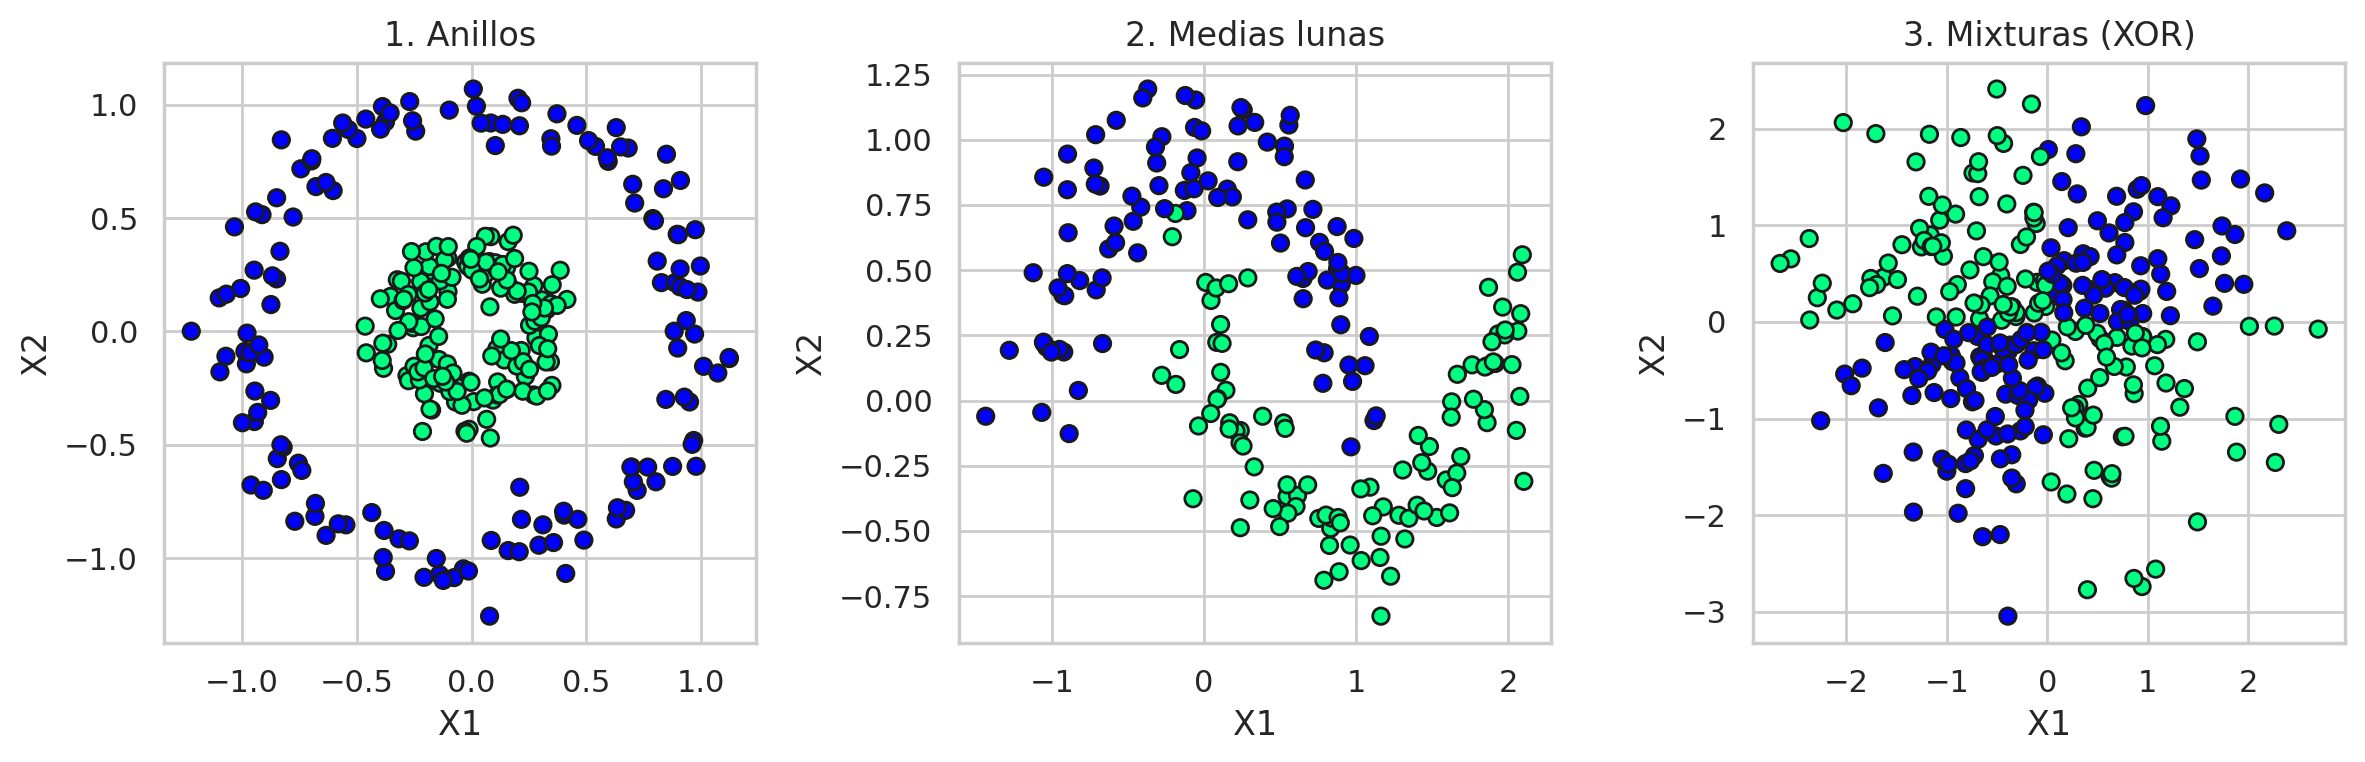

In [2]:
# Juguete 1: ANILLOS (un grupo rodea al otro)
Xc, yc = make_circles(n_samples=300, noise=0.08, factor=0.3, random_state=123)
# Juguete 2: medias lunas
Xm, ym = make_moons(n_samples=200, noise=0.15, random_state=123)
# Juguete 3: mixturas (XOR)
rng = np.random.RandomState(0)
Xx = rng.randn(300, 2)
yx = np.logical_xor(Xx[:, 0] > 0, Xx[:, 1] > 0).astype(int)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (X, y, t) in zip(ax, [(Xc, yc, '1. Anillos'), (Xm, ym, '2. Medias lunas'), (Xx, yx, '3. Mixturas (XOR)')]):
    a.scatter(X[:, 0], X[:, 1], c=y, s=35, cmap='winter', edgecolor='k')
    a.set_title(t)
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.tight_layout()
plt.show()

En los tres casos, **ninguna recta** puede separar bien las dos clases. Lo comprobamos ajustando una SVM **lineal** y dibujando sus regiones de decisión:

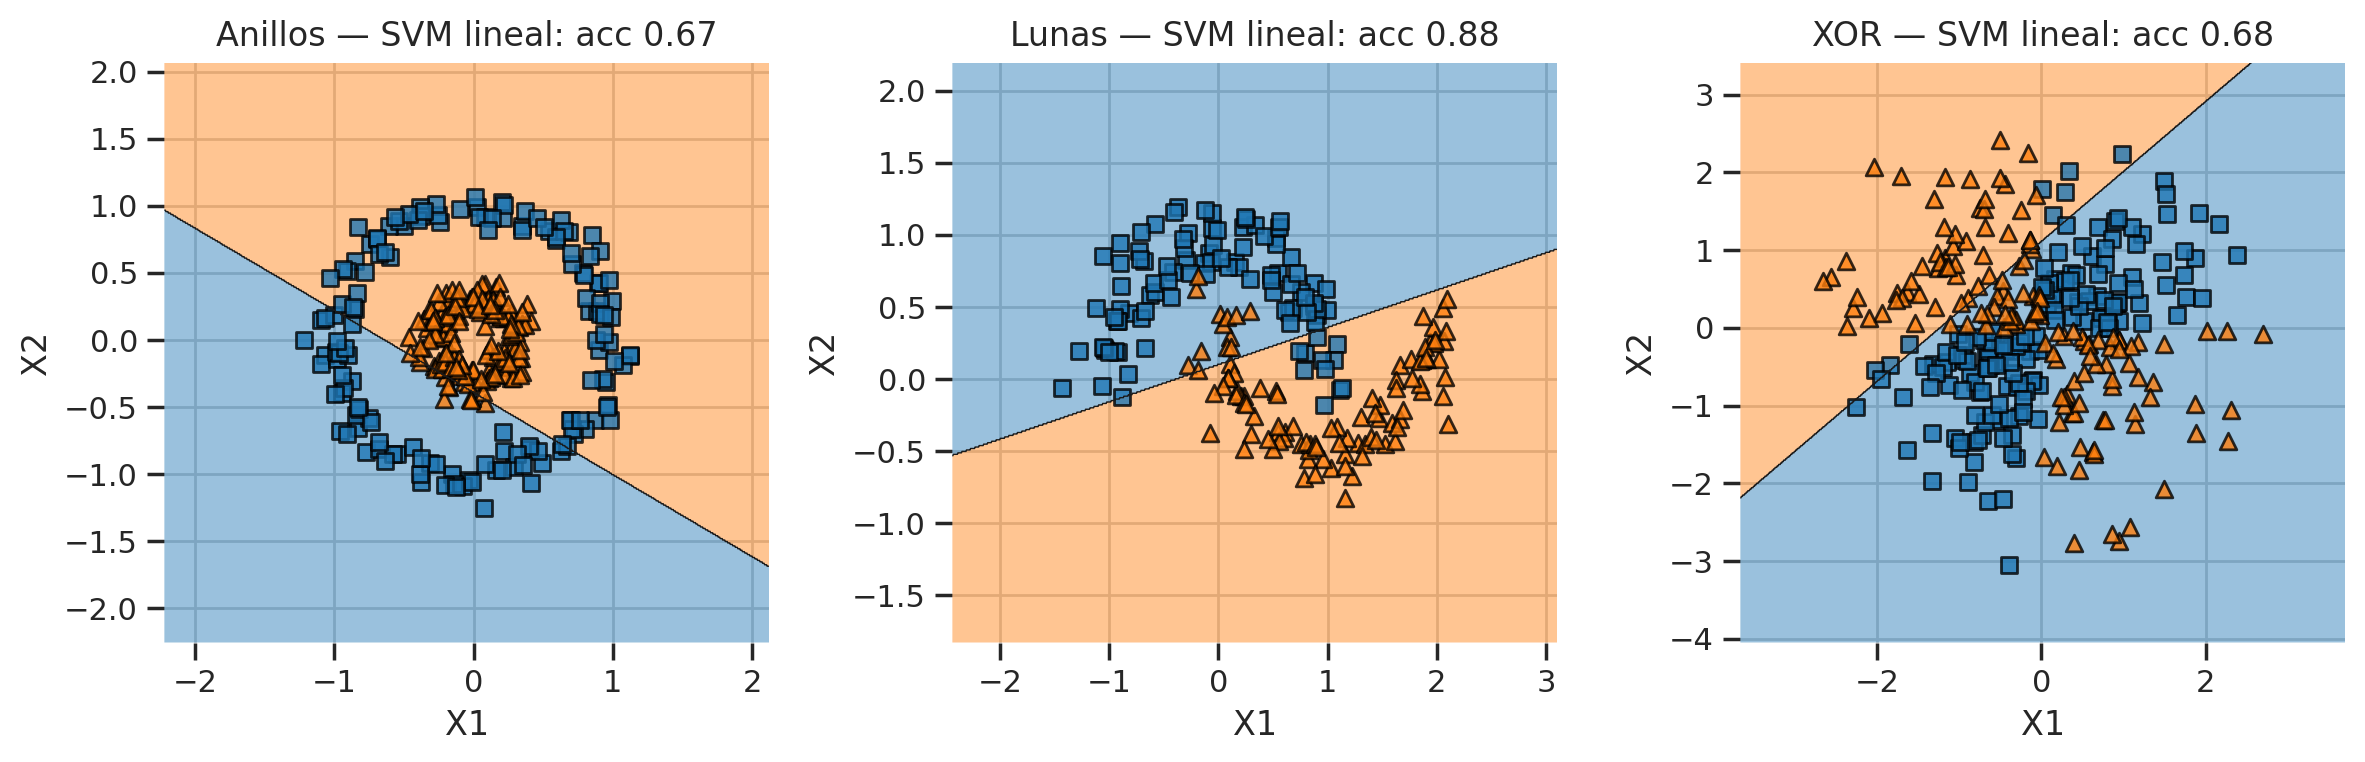

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (X, y, t) in zip(ax, [(Xc, yc, 'Anillos'), (Xm, ym, 'Lunas'), (Xx, yx, 'XOR')]):
    m = SVC(kernel='linear').fit(X, y)
    plot_decision_regions(X=X, y=y, clf=m, ax=a, legend=0)
    a.set_title(f'{t} — SVM lineal: acc {m.score(X, y):.2f}'); a.set_xlabel('X1'); a.set_ylabel('X2')
plt.tight_layout()
plt.show()

La recta deja enormes errores: en los anillos apenas acierta el 67 %, porque **una clase rodea a la otra** y no hay lado "izquierdo/derecho" que valga. Necesitamos fronteras **curvas**. Veamos la idea que lo hace posible.



## <font color="steelblue">1.1. La idea: aumentar la dimensión</font>

El truco conceptual es **añadir dimensiones** construidas a partir de las originales. Tomemos los **anillos**: en 2D no son separables, pero fijémonos en la **distancia al centro**. Los puntos del anillo interior están **cerca** del origen y los del exterior, **lejos**. Si añadimos una tercera coordenada

$$z = x_1^2 + x_2^2$$

(el cuadrado de la distancia al origen), los dos anillos se separan en altura: el interior queda **abajo** y el exterior **arriba**. En ese espacio 3D, ¡un simple **plano horizontal** los separa! Lo visualizamos de forma **interactiva** (gira la figura con el ratón para verla desde distintos ángulos y observar las proyecciones):

In [5]:
import plotly.graph_objects as go

z = Xc[:, 0]**2 + Xc[:, 1]**2
fig = go.Figure()
for cls, color, name in [(0, '#1f77b4', 'grupo 0 (anillo exterior)'), (1, '#2ca02c', 'grupo 1 (anillo interior)')]:
    m = yc == cls
    fig.add_trace(go.Scatter3d(x=Xc[m, 0], y=Xc[m, 1], z=z[m], mode='markers',
                               marker=dict(size=4, color=color), name=name))
gx, gy = np.meshgrid(np.linspace(-1.2, 1.2, 12), np.linspace(-1.2, 1.2, 12))
fig.add_trace(go.Surface(x=gx, y=gy, z=0.5*np.ones_like(gx), showscale=False, opacity=0.35,
                         colorscale=[[0, 'gray'], [1, 'gray']], name='plano z=0.5'))
fig.update_layout(title='Anillos elevados a 3D (gira la figura con el ratón)',
                  scene=dict(xaxis_title='X1', yaxis_title='X2', zaxis_title='z = X1² + X2²'),
                  width=800, height=600, legend=dict(x=0, y=1))
fig.show()

Lo que en 2D era una frontera **circular** se ha convertido en 3D en un **plano** (la lámina gris). Si giras la figura, lo verás claramente: **mirándola desde arriba** (en el eje $z$) recuperas los **anillos originales** en el plano $X_1$–$X_2$, mientras que **mirándola de lado** los dos grupos aparecen separados **en altura** por el plano. Esta es la idea central: **proyectar a más dimensiones** ($\phi:\mathbb{R}^2\to\mathbb{R}^3$) para que el problema se vuelva **linealmente separable**. La transformación que hemos usado de forma implícita es una de las infinitas posibles; un ejemplo clásico es

$$\phi(x_1, x_2) = \bigl(x_1^2,\ \sqrt{2}\,x_1 x_2,\ x_2^2\bigr).$$

Pero quedan dos preguntas: ¿qué transformación elegir? y ¿no es carísimo calcular muchas (o infinitas) dimensiones nuevas? La respuesta a ambas es el **kernel**.

## <font color="steelblue">1.2. El truco del kernel</font>

Recordemos del cuaderno anterior que la SVM, en su forma **dual**, **solo usa los datos a través de productos escalares** $\langle \mathbf{x}_i, \mathbf{x}_j\rangle = \mathbf{x}_i^\top\mathbf{x}_j$, y que la función de decisión es

$$f(\mathbf{x}) = \sum_{i\in\text{SV}} \alpha_i y_i\, \langle \mathbf{x}_i, \mathbf{x}\rangle + \beta_0.$$

Esta observación es más profunda de lo que parece: el algoritmo **nunca necesita las coordenadas** de los puntos por separado, solo **cómo de parecidos** son entre sí (su producto escalar). Esta propiedad tiene un nombre —los métodos que la cumplen se llaman **kernelizables**— y es la puerta que abre todo lo que sigue.

Para conseguir fronteras curvas, la idea natural es **proyectar** los datos a un espacio de más dimensiones con una función $\phi$, donde las clases sí sean **linealmente separables**, y ajustar allí un hiperplano. El problema es el **coste**: ese espacio puede tener muchísimas dimensiones (con polinomios de grado $d$ sobre $p$ variables, el número de términos **explota**), y construir y almacenar cada $\phi(\mathbf{x})$ se vuelve inviable.

Pero acabamos de ver que la SVM **solo necesita productos escalares**. Si proyectamos con $\phi$, todo lo que necesitamos son productos escalares **en el nuevo espacio**: $\langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j)\rangle$. La idea brillante es que para muchas $\phi$ ese producto escalar se puede calcular **directamente** con una función sencilla de los vectores **originales**, sin construir $\phi$. Esa función es el **kernel**:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \langle \phi(\mathbf{x}_i), \phi(\mathbf{x}_j)\rangle.$$

Veámoslo con la $\phi$ de antes. Si $\phi(\mathbf{x}) = (x_1^2, \sqrt{2}x_1x_2, x_2^2)$, entonces

$$\langle \phi(\mathbf{x}), \phi(\mathbf{z})\rangle = x_1^2 z_1^2 + 2x_1x_2 z_1 z_2 + x_2^2 z_2^2 = (x_1 z_1 + x_2 z_2)^2 = \langle \mathbf{x}, \mathbf{z}\rangle^2.$$

¡Asombroso! Calcular el producto escalar en 3D es tan simple como **elevar al cuadrado** el producto escalar en 2D. Fíjate en el ahorro: en lugar de (1) llevar cada punto a 3D y (2) multiplicar allí, haces **una** multiplicación en 2D y la elevas al cuadrado. El resultado es **idéntico**, pero el trabajo se hace en el espacio original, pequeño.

Sustituyendo $\langle\mathbf{x}_i,\mathbf{x}_j\rangle$ por $K(\mathbf{x}_i,\mathbf{x}_j)$ en el problema dual, obtenemos la frontera en el espacio aumentado **sin pisar nunca ese espacio**. A esto se le llama **truco del kernel**: cambiar productos escalares por evaluaciones del kernel para trabajar, **implícitamente**, en un espacio de altísima dimensión con el coste de calcular en el original. La frontera es **lineal en el espacio de $\phi$**, pero **curva** al proyectarla de vuelta al espacio de los datos: ahí está la ganancia.

No cualquier función vale: $K$ debe corresponder a un producto escalar en **algún** espacio. La condición formal (**teorema de Mercer**) es que $K$ sea **simétrica** y **semidefinida positiva** —intuitivamente, que se comporte como una medida de **similitud** válida—. La ventaja práctica es que, cumplida esa condición, **ni siquiera necesitamos conocer $\phi$**: basta con elegir un buen kernel.

El truco permite incluso trabajar en espacios de **dimensión infinita**.

## <font color="steelblue">1.3. Tipos de kernel</font>

Cada kernel corresponde a una proyección $\phi$ distinta. Los más habituales son:

* **Lineal**: $K(\mathbf{x}_i,\mathbf{x}_j) = \mathbf{x}_i^\top\mathbf{x}_j$. No aumenta la dimensión; reproduce la SVM lineal del cuaderno anterior. Es la opción de referencia cuando hay **muchas más variables que muestras** (texto, genómica), donde los datos ya suelen ser separables sin proyectar y un kernel complejo solo añadiría sobreajuste.
* **Polinómico**: $K(\mathbf{x}_i,\mathbf{x}_j) = (\gamma\,\mathbf{x}_i^\top\mathbf{x}_j + c)^d$. Genera fronteras curvas de grado $d$ (con $d=1, c=0$ es el lineal). No conviene $d>5$ por sobreajuste. Hiperparámetros: $d$ (`degree`), $\gamma$ (`gamma`) y $c$ (`coef0`). Captura **interacciones** entre variables hasta el grado $d$; el término $c$ (`coef0`) regula el peso relativo de los términos de grado alto frente a los de grado bajo.
* **Gaussiano o RBF** (*radial basis function*): $K(\mathbf{x}_i,\mathbf{x}_j) = \exp\bigl(-\gamma\lVert \mathbf{x}_i - \mathbf{x}_j\rVert^2\bigr)$, con $\gamma>0$. Es el más usado y versátil; su único hiperparámetro propio es $\gamma$. Actúa como una **medida de similitud local**: vale casi 1 cuando dos puntos están muy próximos y decae rápido hacia 0 al alejarse, de modo que cada vector soporte influye solo en su **entorno**.
* **Sigmoidal**: $K(\mathbf{x}_i,\mathbf{x}_j) = \tanh(\gamma\,\mathbf{x}_i^\top\mathbf{x}_j + \tau)$. Relacionado con las redes neuronales (imita una capa de neuronas). En la práctica se usa **poco**: no es un kernel válido (semidefinido positivo) para todos los valores de sus parámetros, así que puede dar resultados inestables.

Como usaremos sobre todo el RBF, conviene entender sus dos hiperparámetros, que juntos controlan el **sobreajuste**:

* **$\gamma$ — la anchura de influencia de cada punto.**
  * $\gamma$ **pequeño** → cada punto influye **lejos** → fronteras **suaves**, casi lineales (riesgo de *infra*ajuste).
  * $\gamma$ **grande** → cada punto influye solo en su **entorno inmediato** → fronteras muy **onduladas** que se ciñen a cada dato (riesgo de *sobre*ajuste, «islas» alrededor de puntos sueltos).
* **$C$ — el coste de los errores (igual que en la SVM lineal).**
  * $C$ **pequeño** → margen ancho, tolera errores → frontera más **simple** (más regularización).
  * $C$ **grande** → penaliza cada error → frontera más **ajustada** al entrenamiento (menos regularización).

$\gamma$ y $C$ **interactúan**, así que se ajustan **a la vez** (una rejilla 2D por validación cruzada, típicamente en escala logarítmica). El patrón habitual es un «valle» de buen rendimiento: combinaciones de $\gamma$ alto con $C$ alto llevan al sobreajuste, y de $\gamma$ bajo con $C$ bajo, al infraajuste.

No hay un kernel universalmente mejor: depende del problema. Como regla práctica, **el RBF es la opción por defecto recomendada**, porque solo tiene dos hiperparámetros ($\gamma$ y $C$) y su flexibilidad abarca desde casi lineal hasta muy complejo. Una guía rápida:

| Situación | Kernel sugerido |
|---|---|
| Muchas variables, pocas muestras (texto, genómica) | **Lineal** |
| Datos «normales», relación no lineal desconocida | **RBF** (punto de partida) |
| Se sabe que importan interacciones de cierto grado | **Polinómico** (`degree` bajo) |
| — | Sigmoidal (rara vez; suele preferirse una red neuronal) |

**Dos cautelas prácticas** con cualquier kernel:

* **Estandarizar siempre.** El polinómico y el RBF dependen de productos escalares y distancias, así que las variables de mayor escala **dominarían** el kernel. La estandarización previa (que hace `preprocesar_datos`) es imprescindible.
* **Coste computacional.** Los kernels no lineales trabajan con la **matriz de kernel** ($n\times n$), cuyo coste crece con el cuadrado (o más) del número de muestras: con decenas de miles de datos, `SVC` con kernel se vuelve lento y conviene plantearse `LinearSVC` o aproximaciones (`Nystroem`, *random features*).

## <font color="steelblue">1.4. Interpretación geométrica de los kernels</font>

Hay una forma unificada de entender **cualquier** kernel. La función de decisión

$$f(\mathbf{x}) = \sum_{i\in\text{SV}} \alpha_i y_i\, K(\mathbf{x}_i, \mathbf{x}) + \beta_0$$

es una **votación ponderada de similitudes**: cada vector soporte $\mathbf{x}_i$ "vota" por su clase $y_i$ con una influencia $K(\mathbf{x}_i,\mathbf{x})$ que mide **cuánto se parece** el punto nuevo $\mathbf{x}$ a ese vector soporte. Así pues, **el kernel es una medida de similitud**, y su forma determina la geometría de la frontera.

Conviene desglosar los tres factores de cada sumando, porque cada uno tiene un papel:

* **$y_i \in \{-1,+1\}$** — la **dirección del voto**: el vector soporte empuja al punto nuevo hacia **su** clase.
* **$K(\mathbf{x}_i,\mathbf{x})$** — la **fuerza del voto**: cuánto se parece $\mathbf{x}$ a ese vector soporte (siempre según el kernel elegido).
* **$\alpha_i \ge 0$** — la **importancia** de ese vector soporte, aprendida al entrenar: los puntos más difíciles (junto a la frontera) reciben un $\alpha_i$ mayor. Los puntos con $\alpha_i=0$ **no votan** —no son vectores soporte— y por eso el sumatorio recorre solo el conjunto SV.

El resultado se lee por el **signo**: si los «parecidos» a $\mathbf{x}$ son mayoritariamente de una clase, $f(\mathbf{x})$ toma su signo y esa es la predicción. Visto así, **la SVM kernelizada es un pariente sofisticado del $k$-NN**: en lugar de contar los vecinos más cercanos, pondera **todos** los vectores soporte por su similitud (definida por el kernel) y por su importancia $\alpha_i$.

Hay dos grandes familias:

* **Basados en el producto escalar** (lineal, polinómico, sigmoidal): la similitud depende de $\mathbf{x}_i^\top\mathbf{x}$, es decir, del **alineamiento** (ángulo y magnitud) entre los vectores. Son similitudes **globales y direccionales**: dos puntos alejados pero bien alineados pueden parecerse mucho.
* **Basados en la distancia** (RBF): la similitud depende de $\lVert\mathbf{x}_i-\mathbf{x}\rVert$, es decir, de la **cercanía** entre los puntos. Es una similitud **local**: solo se parecen los puntos que están físicamente próximos.

Qué significa cada uno:

* **Lineal** $K=\mathbf{x}_i^\top\mathbf{x}$: la similitud crece **linealmente** con la proyección de $\mathbf{x}$ sobre $\mathbf{x}_i$. Sus "curvas de igual similitud" son **rectas** perpendiculares a $\mathbf{x}_i$; por eso la frontera resultante es **plana**.
* **Polinómico** $K=(\gamma\,\mathbf{x}_i^\top\mathbf{x}+c)^d$: eleva el producto escalar a una potencia, generando implícitamente **todos los productos** de las variables hasta grado $d$ (interacciones y potencias). Sus curvas de similitud son **polinómicas**; con $d$ par puede crear regiones **cerradas** (elipses) y con $d$ impar, abiertas. $d$ controla la complejidad de la curvatura y $c$ (`coef0`) el equilibrio entre términos de grado alto y bajo.
* **RBF** $K=\exp(-\gamma\lVert\mathbf{x}_i-\mathbf{x}\rVert^2)$: una **campana** centrada en $\mathbf{x}_i$ que vale 1 en él y decae con la distancia. Sus curvas de similitud son **círculos concéntricos** y su influencia es **local**. El parámetro $\gamma$ es el **ancho** de esa campana: $\gamma$ grande = campana estrecha = influencia muy local (fronteras onduladas); $\gamma$ pequeño = campana ancha = influencia extensa (fronteras suaves).
* **Sigmoidal** $K=\tanh(\gamma\,\mathbf{x}_i^\top\mathbf{x}+\tau)$: pasa el producto escalar por una **S** (tanh) que **satura** en $\pm1$. Se comporta como una "neurona", y de hecho una SVM sigmoidal se relaciona con una red neuronal de una capa.

La conexión clave entre estos mapas de similitud y la clasificación es esta: la **frontera** es el lugar donde $f(\mathbf{x})=0$, es decir, donde la votación de los vectores soporte de una clase **empata**.

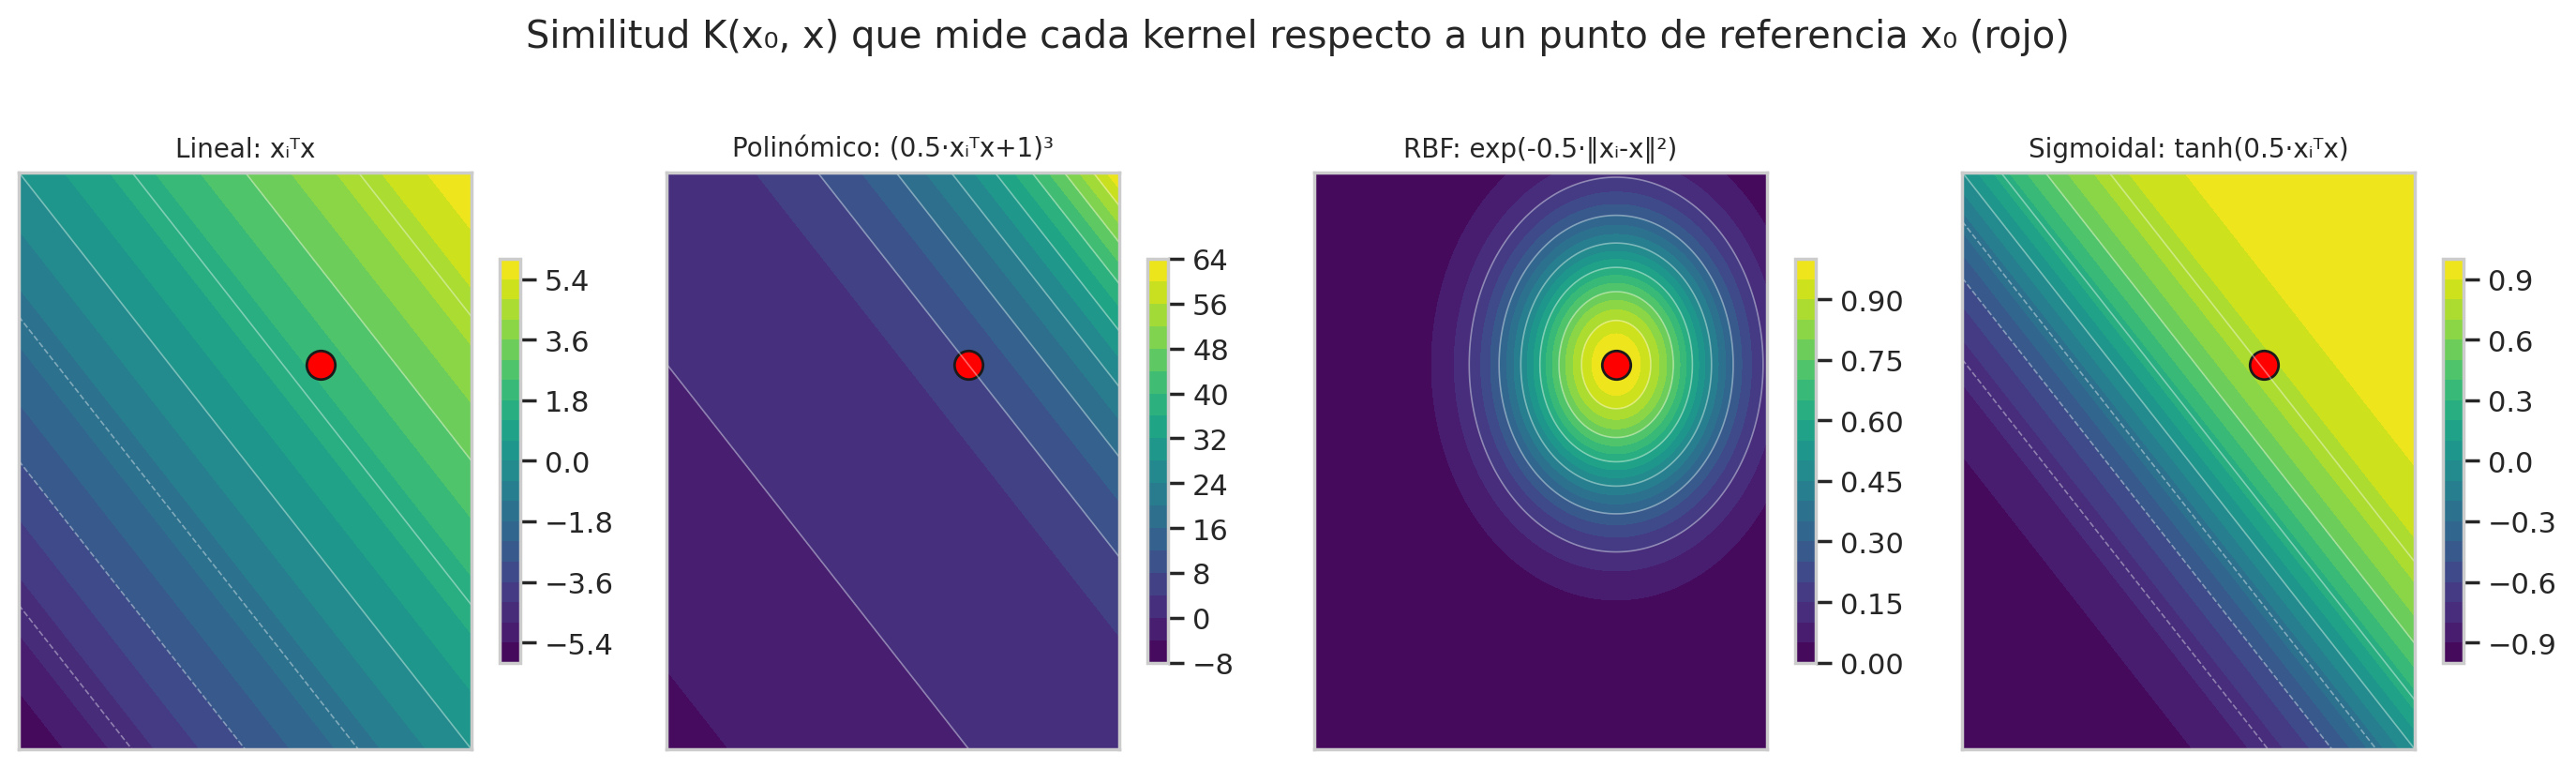

In [6]:
# Solución gráfica de cada uno de los kernels
gx, gy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
P = np.c_[gx.ravel(), gy.ravel()]
x0 = np.array([1.0, 1.0])
dot = P @ x0; d2 = ((P - x0)**2).sum(1)
kernels = {'Lineal: xᵢᵀx': dot, 'Polinómico: (0.5·xᵢᵀx+1)³': (0.5*dot + 1)**3,
           'RBF: exp(-0.5·‖xᵢ-x‖²)': np.exp(-0.5*d2), 'Sigmoidal: tanh(0.5·xᵢᵀx)': np.tanh(0.5*dot)}
fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a, (t, v) in zip(ax, kernels.items()):
    cf = a.contourf(gx, gy, v.reshape(gx.shape), levels=20, cmap='viridis')
    a.contour(gx, gy, v.reshape(gx.shape), levels=8, colors='white', alpha=.4, linewidths=.6)
    a.scatter(*x0, color='red', s=120, edgecolor='k')
    a.set_title(t, fontsize=10)
    a.set_xticks([])
    a.set_yticks([])
    plt.colorbar(cf, ax=a, shrink=.7)
plt.suptitle('Similitud K(x₀, x) que mide cada kernel respecto a un punto de referencia x₀ (rojo)', y=1.02)
plt.tight_layout()
plt.show()

Cada mapa muestra **a qué puntos del plano considera "parecidos" a $\mathbf{x}_0$** ese kernel. El **lineal** reparte la similitud en **franjas rectas** (de ahí las fronteras planas); el **polinómico** las curva; el **RBF** la concentra en un **halo circular** alrededor de $\mathbf{x}_0$ (influencia local que decae con la distancia); el **sigmoidal** crea una transición tipo rampa **saturada**. Como la frontera final combina estas similitudes centradas en los vectores soporte, **su geometría hereda la forma del kernel**.

Profundizamos en el **RBF** por su importancia. Es una **campana de Gauss centrada en cada vector soporte**, de modo que la función de decisión es una **suma de campanas** que votan con una influencia que decae con la distancia. Su parámetro $\gamma$ controla la **anchura** de esas campanas:

* **$\gamma$ pequeño** → campanas **anchas**: influencia de largo alcance, frontera **suave** (casi lineal). Riesgo de **infraajuste**.
* **$\gamma$ grande** → campanas **estrechas**: influencia muy local, frontera **ondulada**. Riesgo de **sobreajuste**.

Visualizamos las campanas (en 1D) para distintos $\gamma$:

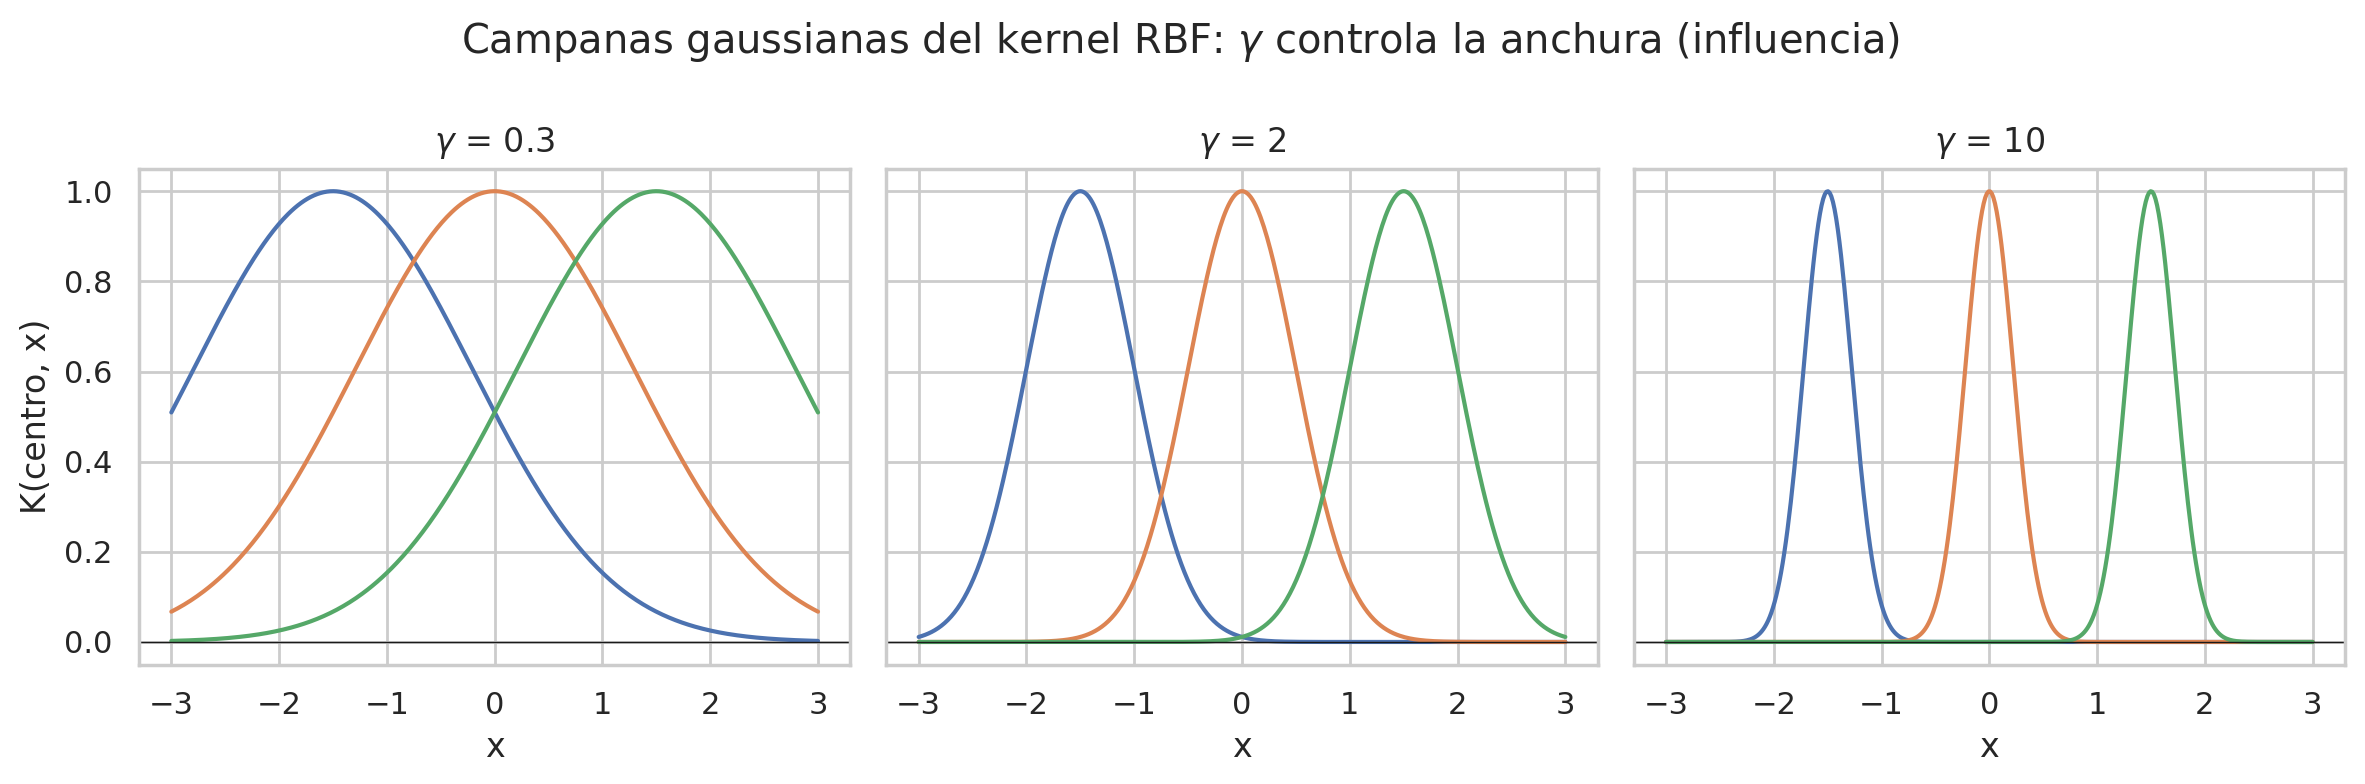

In [7]:
xx = np.linspace(-3, 3, 400)
centros = [-1.5, 0, 1.5]
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for a, g in zip(ax, [0.3, 2, 10]):
    for c in centros:
        a.plot(xx, np.exp(-g * (xx - c)**2))
    a.set_title(rf'$\gamma$ = {g}')
    a.set_xlabel('x')
    a.axhline(0, color='k', lw=.5)
ax[0].set_ylabel('K(centro, x)')
plt.suptitle(r'Campanas gaussianas del kernel RBF: $\gamma$ controla la anchura (influencia)')
plt.tight_layout()
plt.show()

Con $\gamma$ pequeño las campanas son anchas y se solapan (influencia de largo alcance → frontera suave); con $\gamma$ grande son picudas y aisladas (influencia local → frontera flexible). Elegir $\gamma$ es, por tanto, elegir **cuán local** queremos que sea el clasificador.

## <font color="steelblue">1.5. Los hiperparámetros C y γ, y el sobreajuste</font>

El RBF tiene **dos** mandos que hay que ajustar **conjuntamente** por validación cruzada:

* **$C$** (común a toda SVM): controla la **dureza del margen** (cuánto penalizamos las violaciones). $C$ grande → margen estrecho, menos errores en entrenamiento, más varianza; $C$ pequeño → margen ancho, tolera errores, frontera más simple (más sesgo, más regularización).
* **$\gamma$**: controla la **flexibilidad** de la frontera (anchura de las campanas), como acabamos de ver. $\gamma$ grande → campanas estrechas, influencia muy **local**, frontera muy ondulada; $\gamma$ pequeño → campanas anchas, influencia **extensa**, frontera casi lineal.

La clave es que **ambos empujan en la misma dirección**: subir $C$ **o** subir $\gamma$ hace la frontera **más compleja** (más varianza, más riesgo de sobreajuste); bajarlos la hace **más simple** (más sesgo, más riesgo de infraajuste). Pero lo hacen por mecanismos distintos —$C$ desde la **tolerancia a errores** y $\gamma$ desde el **alcance de cada punto**—, y por eso **interactúan** y hay que explorarlos **a la vez**, no uno por uno. Ayuda pensar en las **cuatro esquinas** del mapa:

| | **$\gamma$ pequeña** (frontera suave) | **$\gamma$ grande** (frontera local) |
|---|---|---|
| **$C$ pequeña** (margen blando) | Muy simple → riesgo de **infraajuste** | Ondulada pero «perdonando» errores; efecto intermedio |
| **$C$ grande** (margen duro) | Frontera suave que respeta casi todos los puntos; suele ser un **buen punto** | Muy compleja, «islas» alrededor de puntos sueltos → **sobreajuste** claro |

Su interacción se ve muy bien sobre las **medias lunas**, variando $\gamma$ (columnas) y $C$ (filas). Al recorrer el mapa conviene fijarse en tres cosas:

* **De izquierda a derecha (γ ↑):** la frontera pasa de casi recta a cada vez más sinuosa, hasta encerrar puntos individuales en «islas».
* **De arriba abajo (C ↑):** la frontera se ciñe más a los datos y el margen se estrecha.
* **La esquina inferior derecha ($C$ y $\gamma$ altos)** es el retrato del **sobreajuste**: acierta casi todo el entrenamiento con una frontera imposible de justificar; la **superior izquierda**, el del **infraajuste**. Las buenas soluciones viven en una **franja diagonal intermedia**.

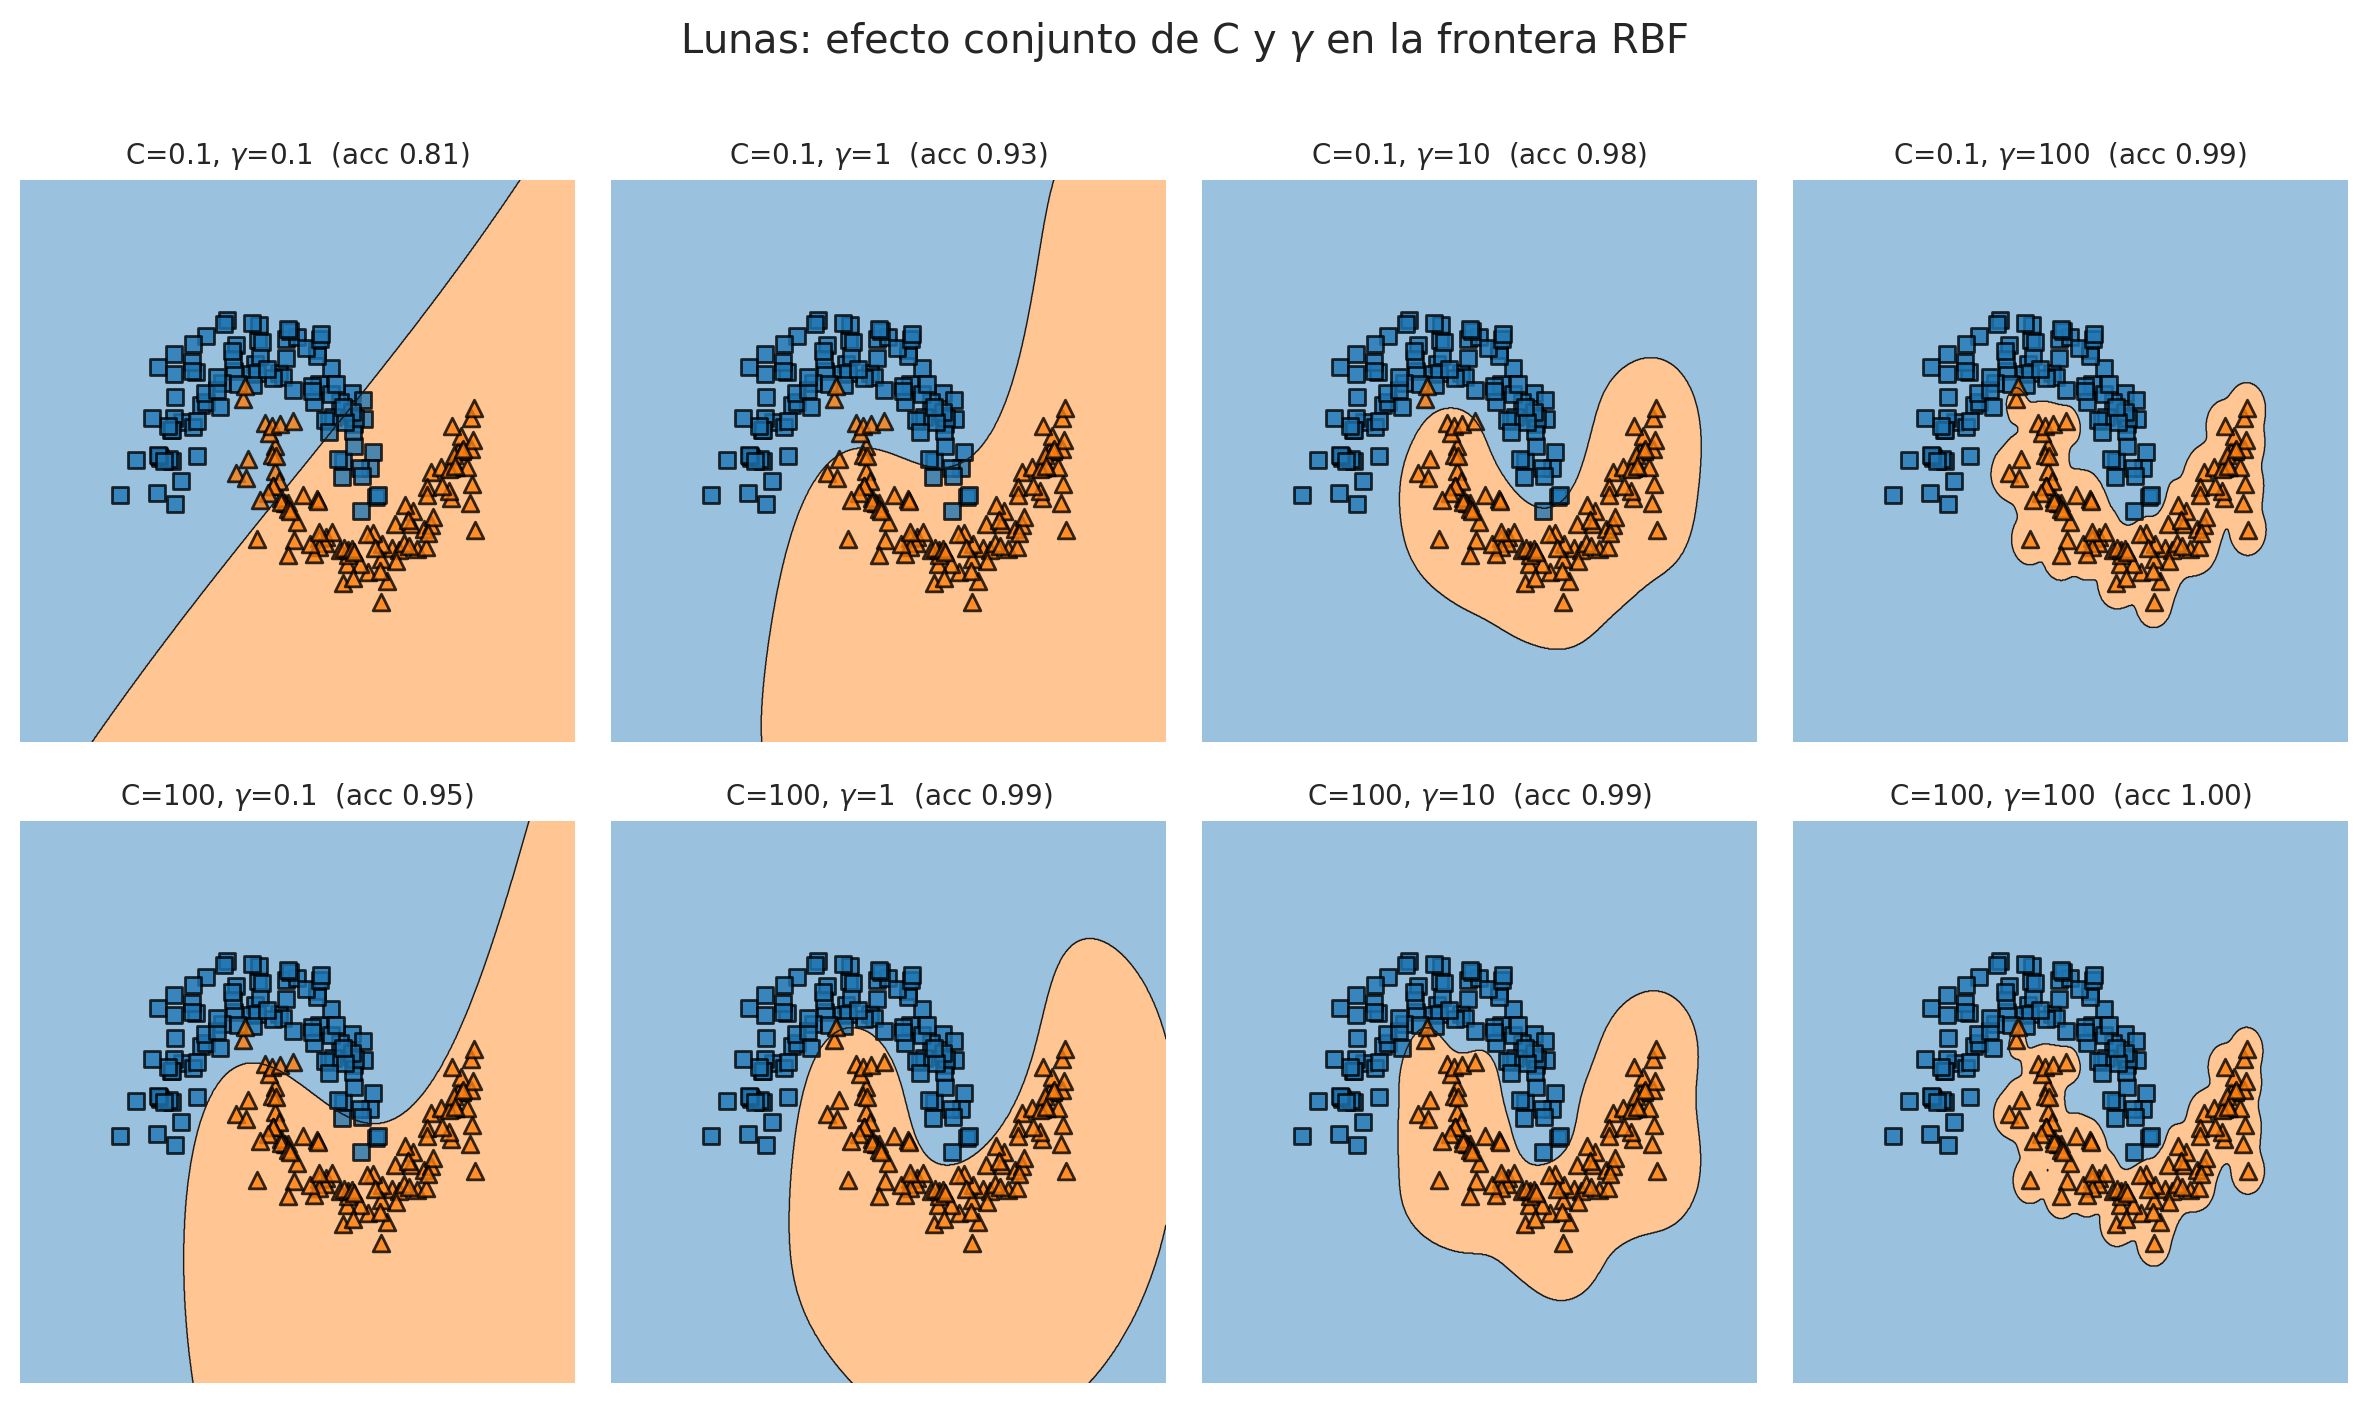

In [8]:
Cs = [0.1, 100]; gammas = [0.1, 1, 10, 100]
fig, ax = plt.subplots(2, 4, figsize=(12, 7))
for i, C in enumerate(Cs):
    for j, g in enumerate(gammas):
        a = ax[i, j]
        m = SVC(kernel='rbf', C=C, gamma=g).fit(Xm, ym)
        plot_decision_regions(X=Xm, y=ym, clf=m, ax=a, legend=0)
        a.set_title(rf'C={C}, $\gamma$={g}  (acc {m.score(Xm, ym):.2f})', fontsize=10)
        a.set_xticks([])
        a.set_yticks([])
plt.suptitle(r'Lunas: efecto conjunto de C y $\gamma$ en la frontera RBF', y=1.0)
plt.tight_layout()
plt.show()

Con $\gamma$ pequeño la frontera es casi recta (infraajuste). Al crecer $\gamma$ se adapta a las lunas, y con $\gamma$ muy grande aparecen "islas" alrededor de puntos aislados (sobreajuste evidente). $C$ modula ese efecto: con $C$ grande el modelo se permite fronteras más retorcidas. El **punto dulce** está en valores intermedios, que buscaremos por validación cruzada.

## <font color="steelblue">1.6. Ventajas, desventajas y elección del kernel</font>

**Ventajas:** las SVM con kernel capturan fronteras **muy complejas**, siguen siendo **robustas** (dependen solo de los vectores soporte) y el truco del kernel las hace **eficientes** pese a trabajar en dimensiones altísimas. **Desventajas:** hay **más hiperparámetros** que ajustar ($C$, $\gamma$, tipo de kernel…), el coste de cálculo **crece** con el número de muestras, pierden **interpretabilidad** (ya no hay coeficientes por variable, así que no aplican métodos como `select_variables`) y `SVC` no da probabilidades salvo activando `probability=True`. **En la práctica:** estandarizar siempre, empezar por el **kernel RBF** y ajustar $C$ y $\gamma$ por validación cruzada.

# <font color="steelblue">2. SVM no lineales en scikit-learn</font>

La clase es **`sklearn.svm.SVC`** (para regresión existe su análoga `SVR`). Está implementada sobre *libsvm*, resuelve el problema **dual** —por eso admite *kernels*— y aborda el multiclase con **uno-contra-uno (OvO)**. Su coste crece entre **cuadrática y cúbicamente** con el número de muestras, así que con decenas de miles de datos conviene `LinearSVC` o una aproximación de kernel (`Nystroem`). Sus parámetros principales:

| Parámetro | Descripción | Por defecto |
|---|---|---|
| **`C`** | Regularización (inversa): grande = margen estrecho, más ajuste; pequeño = margen ancho, más regularización. | `1.0` |
| **`kernel`** | `'linear'`, `'poly'`, `'rbf'`, `'sigmoid'` o uno propio. | `'rbf'` |
| **`degree`** | Grado $d$ del kernel polinómico (ignorado por los demás). | `3` |
| **`gamma`** | Coeficiente $\gamma$ de rbf/poly/sigmoid: `'scale'` = $1/(p\cdot\text{Var}(X))$, `'auto'` = $1/p$, o un valor. | `'scale'` |
| **`coef0`** | Término independiente $c$/$\tau$ en poly y sigmoid. | `0.0` |
| **`class_weight`** | `'balanced'` compensa el desbalanceo de clases. | `None` |
| **`probability`** | Si `True`, habilita `predict_proba` (más lento). | `False` |
| **`random_state`** | Semilla (solo influye si `probability=True`). | `None` |

Otros parámetros útiles: **`tol`** (`1e-3`, tolerancia de parada), **`max_iter`** (`-1` = sin límite; súbelo/limítalo si el ajuste se alarga), **`cache_size`** (`200` MB de caché del kernel; ampliarlo **acelera** con datos grandes), **`shrinking`** (`True`, heurística que acelera la optimización), **`decision_function_shape`** (`'ovr'`/`'ovo'`, forma de la salida de `decision_function` en multiclase) y **`break_ties`** (deshace empates en multiclase, algo más lento).

**Métodos**

`fit`, `predict`, **`decision_function`** (puntuación con signo al hiperplano, útil para la **ROC** y para ordenar por confianza), `score`, y `predict_proba`/`predict_log_proba` **solo si `probability=True`**. Cautela con las probabilidades: se obtienen por un ajuste interno (*Platt scaling*) con validación cruzada, por lo que son **más lentas** y **pueden no coincidir** exactamente con el signo de `decision_function`; si solo necesitas la ROC, usa `decision_function` y ahórrate `probability=True`.

**Atributos tras ajustar**

* **`support_vectors_`** `(n_SV, n_features)` — los **vectores soporte** (las observaciones que definen la frontera).
* **`support_`** — sus **índices** dentro del conjunto de entrenamiento.
* **`n_support_`** `(n_clases,)` — **cuántos** vectores soporte hay **por clase** (un recuento alto sugiere una frontera muy exigente o poca separación).
* **`dual_coef_`** `(n_clases−1, n_SV)` — los coeficientes $\alpha_i y_i$ de cada vector soporte en la función de decisión.
* **`intercept_`** — el término independiente $\beta_0$.
* **`classes_`**, **`n_features_in_`**, **`feature_names_in_`** — etiquetas, y nº/nombres de variables vistas en `fit`.
* **`coef_`** — **solo con `kernel='linear'`**: los pesos $\boldsymbol\beta$ por variable. Con kernels no lineales **no existe** (la frontera no es lineal en el espacio original), por lo que la interpretación pasa por los vectores soporte, no por coeficientes.

Los vemos sobre el banco de datos de los anillos:

In [10]:
m = SVC(kernel='rbf', C=1, gamma='scale').fit(Xc, yc)
print('nº de vectores soporte por clase:', m.n_support_, '| total:', m.support_vectors_.shape[0])
print('exactitud en los anillos:', round(m.score(Xc, yc), 3))
print('decision_function (5 puntos):', np.round(m.decision_function(Xc[:5]), 2))

nº de vectores soporte por clase: [11 10] | total: 21
exactitud en los anillos: 1.0
decision_function (5 puntos): [ 1.61 -1.69  1.7   1.58  1.26]


El RBF clasifica **perfectamente** los anillos con un puñado de vectores soporte repartidos por ambos. `decision_function` da la puntuación con signo (lado y confianza), que usaremos en la ROC.

# <font color="steelblue">3. Aplicaciones</font>





## <font color="steelblue">3.1. Los juguetes: comparación de kernels</font>

Sobre los **anillos**, comparamos los cuatro kernels con sus opciones por defecto:

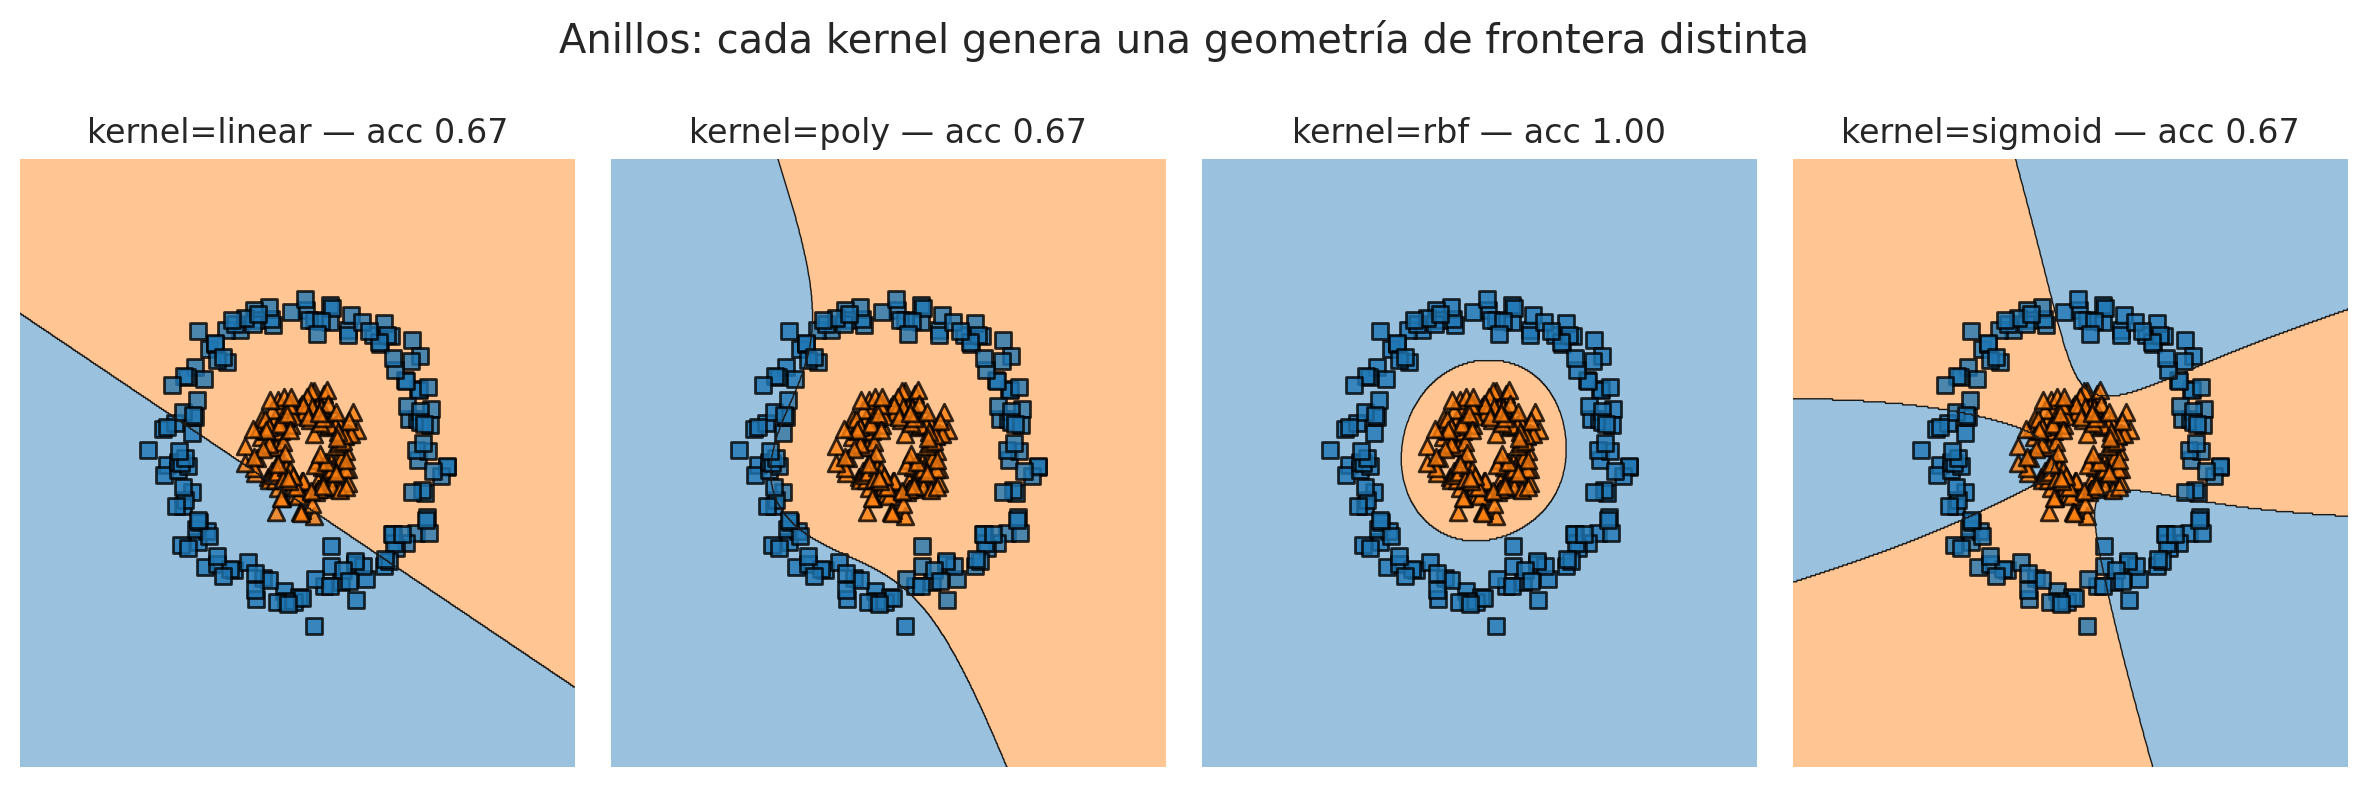

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
for a, k in zip(ax, ['linear', 'poly', 'rbf', 'sigmoid']):
    m = SVC(kernel=k).fit(Xc, yc)
    plot_decision_regions(X=Xc, y=yc, clf=m, ax=a, legend=0)
    a.set_title(f'kernel={k} — acc {m.score(Xc, yc):.2f}')
    a.set_xticks([])
    a.set_yticks([])
plt.suptitle('Anillos: cada kernel genera una geometría de frontera distinta')
plt.tight_layout()
plt.show()

El **RBF** captura a la perfección la estructura circular; el **lineal** y el **sigmoidal** fracasan, y el **polinómico** de grado 3 (impar) tampoco se ajusta bien a una frontera circular (que es de grado par). Esto ilustra que el kernel debe **encajar con la geometría** del problema, y por qué el RBF es una apuesta segura. Ajustamos ahora un RBF óptimo en las **lunas** y las **mixturas** con `GridSearchCV`:

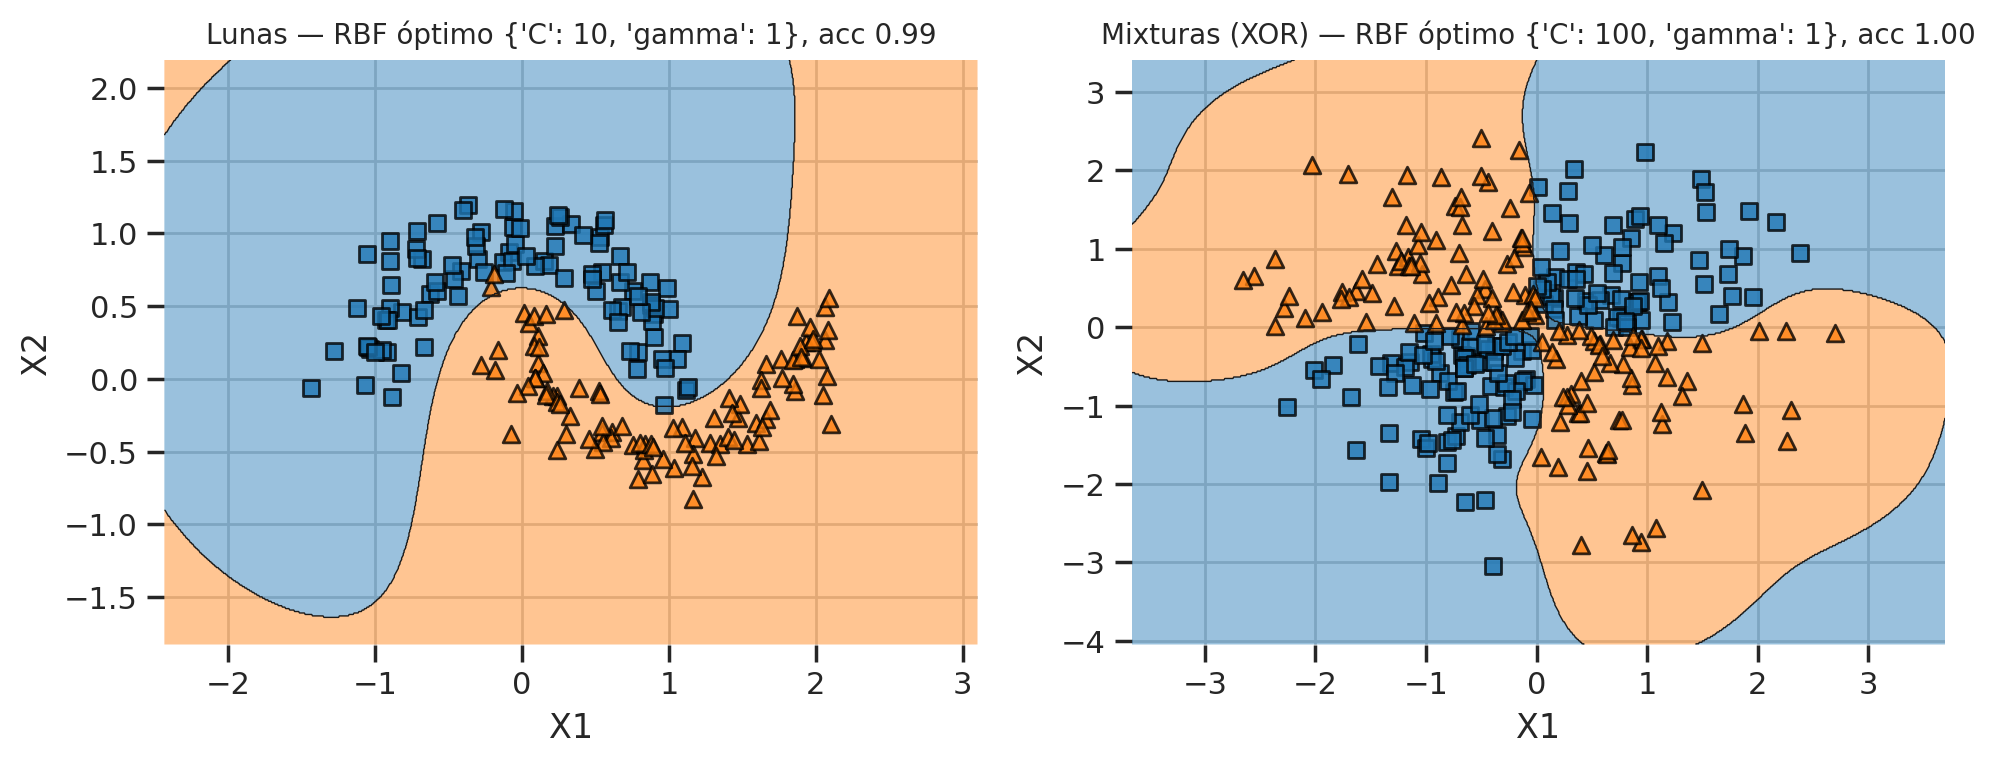

In [12]:
pgrid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': [0.01, 0.1, 1, 10]}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (X, y, t) in zip(ax, [(Xm, ym, 'Lunas'), (Xx, yx, 'Mixturas (XOR)')]):
    gs = GridSearchCV(SVC(kernel='rbf'), pgrid, cv=5).fit(X, y)
    plot_decision_regions(X=X, y=y, clf=gs.best_estimator_, ax=a, legend=0)
    a.set_title(f'{t} — RBF óptimo {gs.best_params_}, acc {gs.score(X, y):.2f}', fontsize=10)
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.tight_layout()
plt.show()

Con el $C$ y $\gamma$ óptimos, el RBF traza fronteras curvas que separan **casi perfectamente** las lunas y el XOR: justo lo que un clasificador lineal no podía lograr.

## <font color="steelblue">3.2. Breast Cancer Wisconsin (2 clases)</font>

Utilizamos el RBF al banco de datos de cáncer de mama y lo comparamos con el resultado lineal del cuaderno anterior.

In [13]:
# Cargamos los datos
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer_clean.csv'
cancer = pd.read_csv(url, index_col=0)
cancer['diagnosis'] = cancer['diagnosis'].astype('category')

Preprocesamos (estandarización, **imprescindible** con RBF, que se basa en distancias) y dividimos.

In [14]:
strain_raw, stest_raw = split_sample(cancer, 'diagnosis', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'diagnosis')
stest,  _    = preprocesar_datos(stest_raw,  'diagnosis', prep)
xtrain, ytrain = strain.drop('diagnosis', axis=1), strain['diagnosis']
xtest,  ytest  = stest.drop('diagnosis', axis=1),  stest['diagnosis']
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Entrenamiento: (398, 30) | Test: (171, 30)


Como las clases **no están equilibradas**, optimizamos y validamos con la **F1 ponderada** (media de la F1 de cada clase pesada por su frecuencia) en lugar de la exactitud: la F1 combina precisión y exhaustividad y no se deja engañar por la clase mayoritaria. Usaremos esta misma métrica en los dos ejemplos reales. Además, tras la búsqueda dibujaremos un **mapa de calor de la validación cruzada** sobre el plano $C \times \gamma$: cada celda muestra la F1 (en CV) de esa combinación de hiperparámetros. Así se ve de un vistazo **cómo cambia la métrica** por la región de parámetros y dónde está el óptimo.

In [15]:
def cv_heatmap(gs):
    r = pd.DataFrame(gs.cv_results_); r['param_gamma'] = r['param_gamma'].astype(str)
    piv = r.pivot(index='param_C', columns='param_gamma', values='mean_test_score')
    piv = piv.reindex(index=sorted(piv.index), columns=['scale', '0.1', '0.01', '0.001'])
    plt.figure(figsize=(7, 5))
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'F1 ponderada (CV)'})
    plt.title(rf'Validación cruzada en el plano C × $\gamma$ — óptimo {gs.best_params_}')
    plt.xlabel(r'$\gamma$')
    plt.ylabel('C')
    plt.show()

Mejores hiperparámetros: {'C': 10, 'gamma': 'scale'} | F1 ponderada CV: 0.985


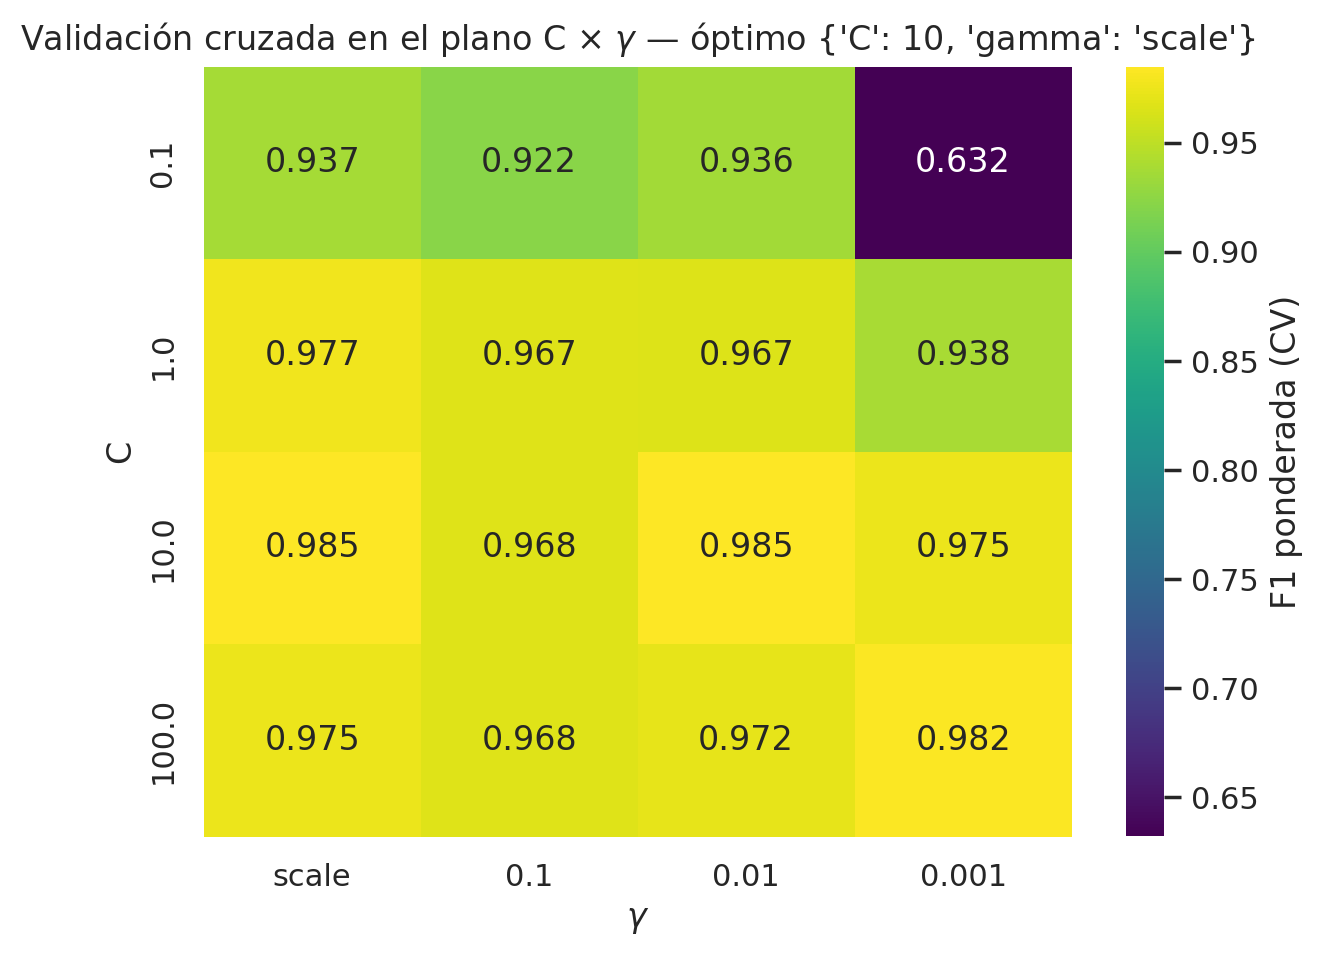

In [16]:
pgrid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 0.01, 0.001]}
gs = GridSearchCV(SVC(kernel='rbf', random_state=123), pgrid, scoring='f1_weighted', cv=KFold(5))
gs.fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_, '| F1 ponderada CV:', round(gs.best_score_, 3))
modelo = gs.best_estimator_
cv_heatmap(gs)

Analizamos el modelo con los hiperparámetros óptimos obtenidos:

In [17]:
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       0.99      1.00      1.00       250
           M       1.00      0.99      0.99       148

    accuracy                           0.99       398
   macro avg       1.00      0.99      0.99       398
weighted avg       1.00      0.99      0.99       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.95      0.95      0.95       107
           M       0.92      0.92      0.92        64

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



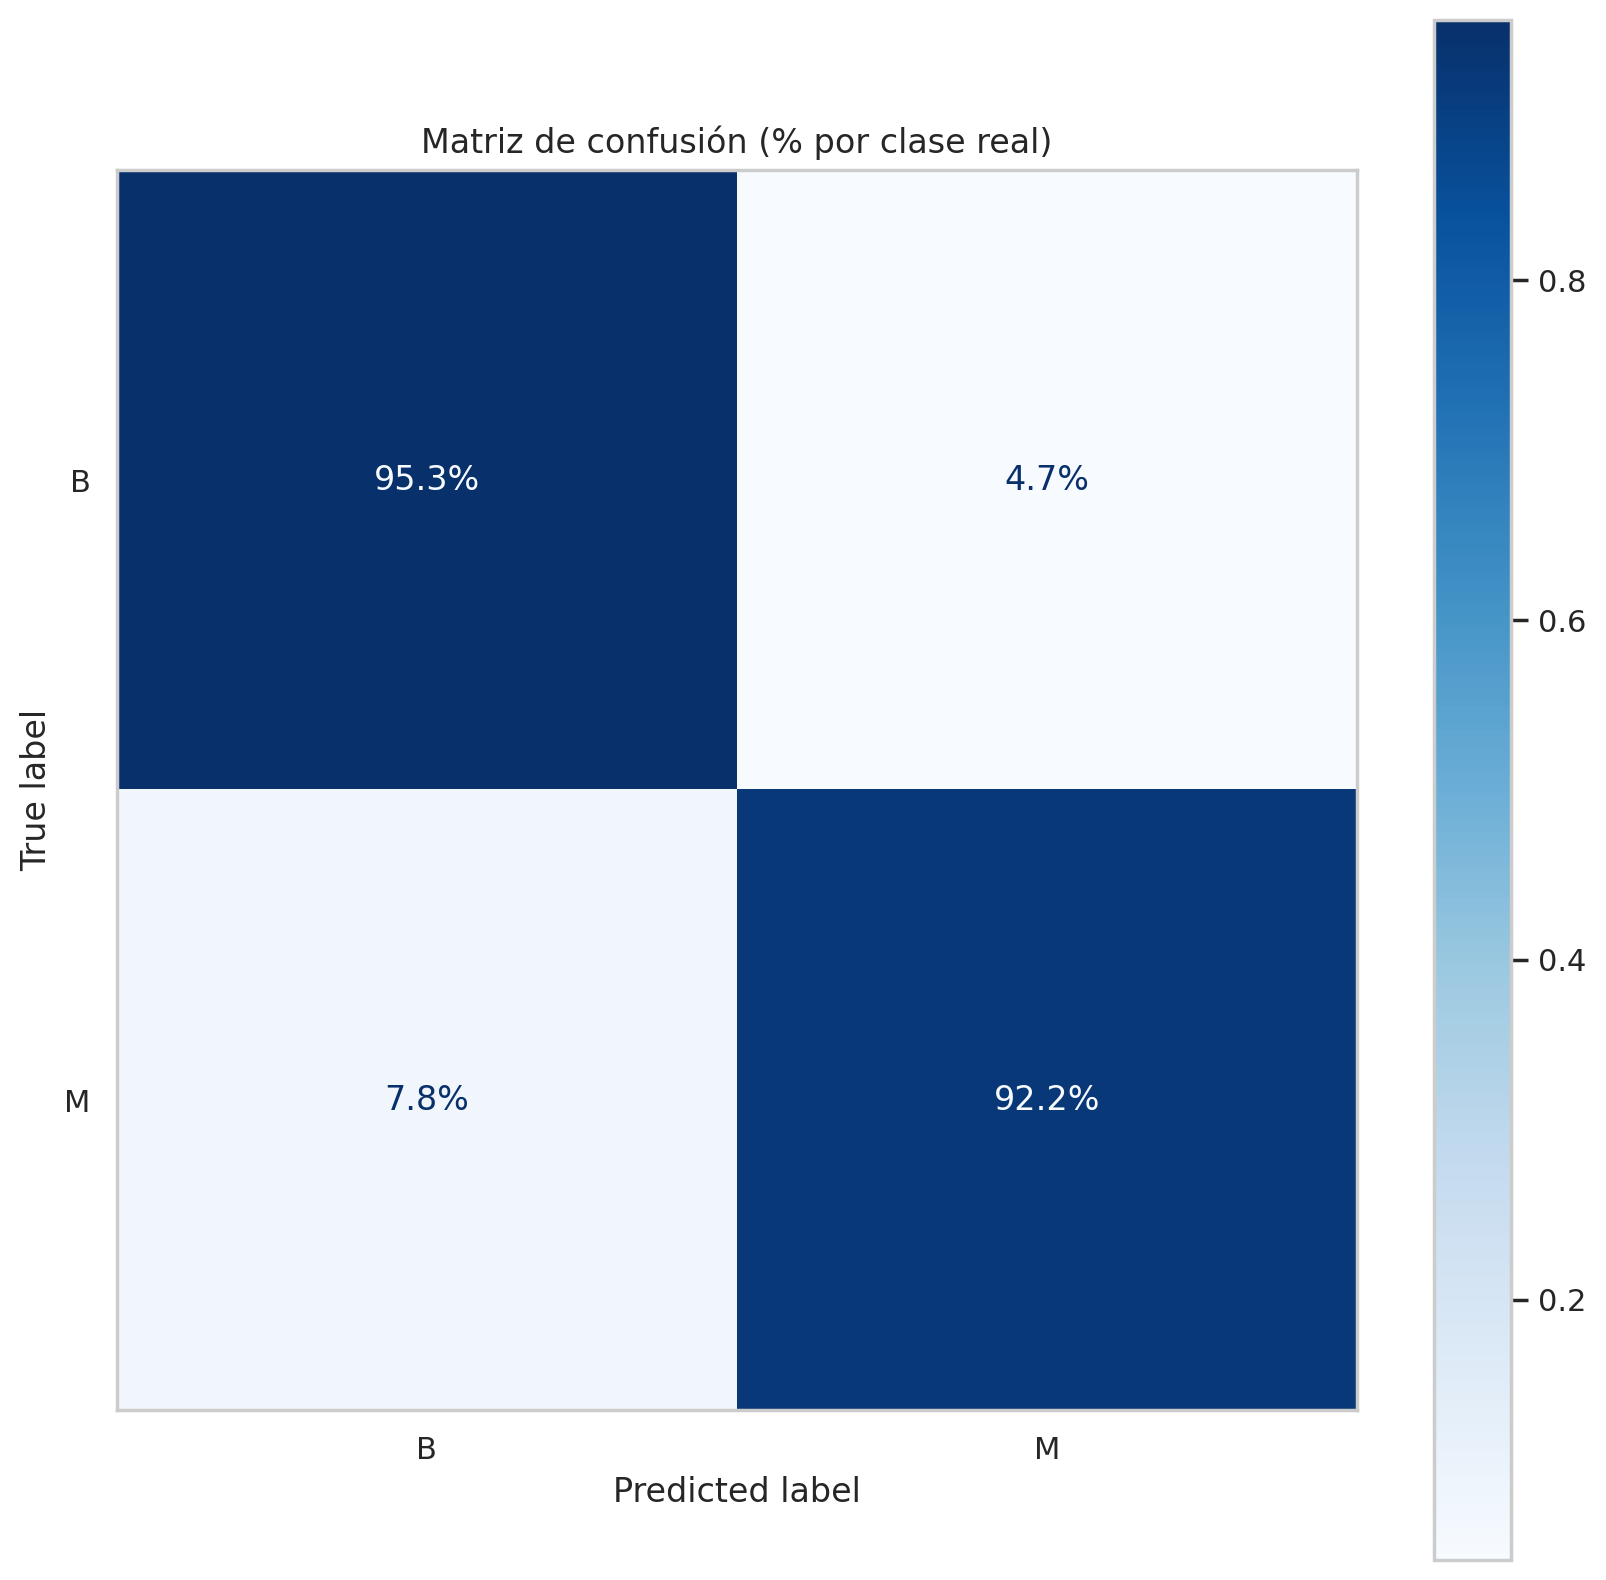

In [18]:
matriz_confusion(modelo, xtest, ytest);

In [19]:
val = validar_modelo(modelo, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.985 +/- 0.020


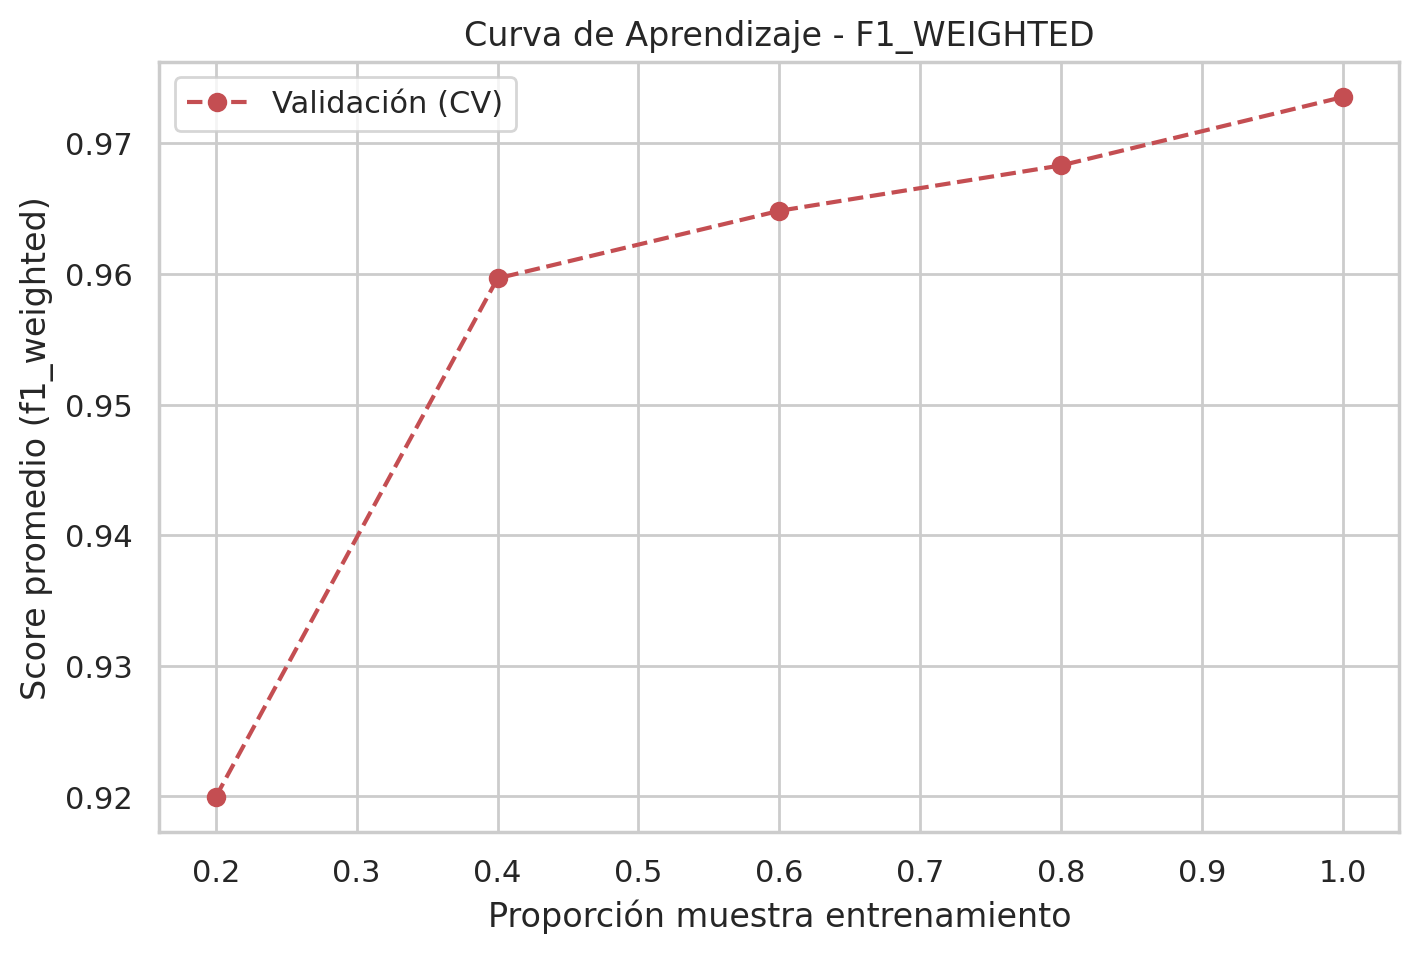

In [20]:
datos_pp, _ = preprocesar_datos(cancer, 'diagnosis')
X = datos_pp.drop('diagnosis', axis=1)
y = datos_pp['diagnosis']
curva_aprendizaje(modelo, X, y, 'f1_weighted', 10);

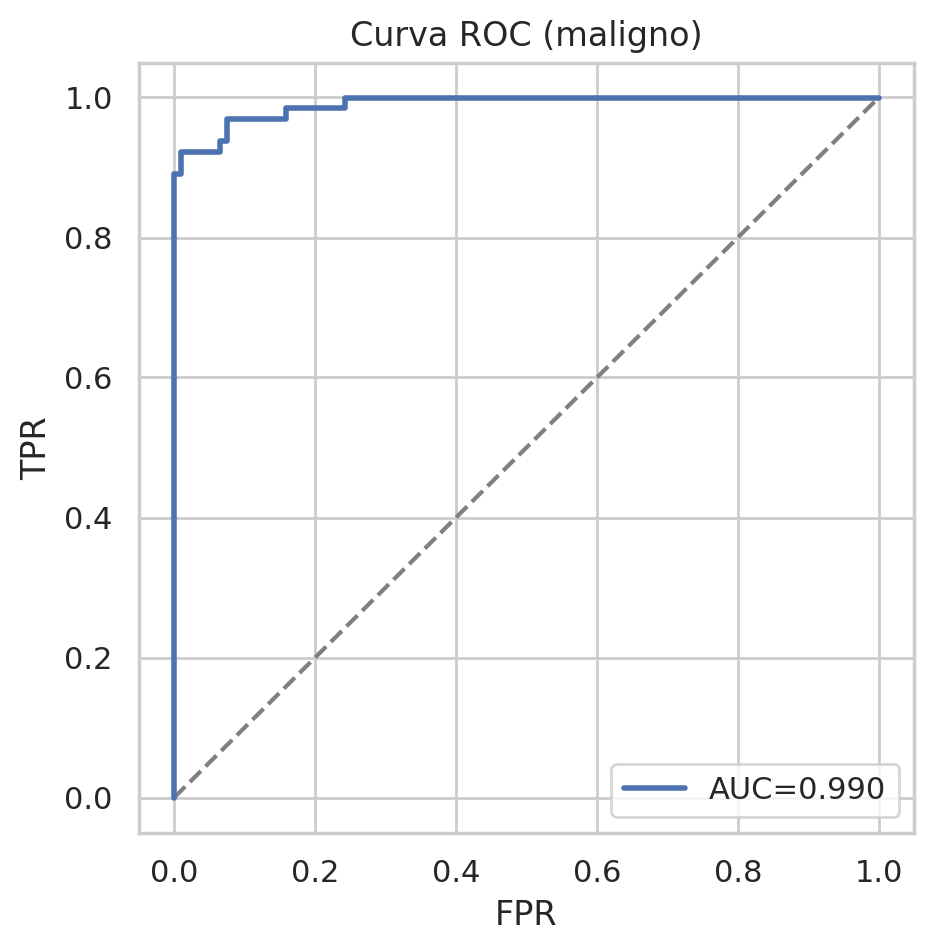

In [21]:
score_M = modelo.decision_function(xtest)
fpr, tpr, _ = roc_curve((ytest == 'M').astype(int), score_M); auc = roc_auc_score((ytest == 'M').astype(int), score_M)
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.plot(fpr, tpr, lw=2, label=f'AUC={auc:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (maligno)')
plt.legend()
plt.show()

El RBF alcanza una F1 ponderada alta (~0.94) que **no supera** a la del lineal del cuaderno anterior. La razón es instructiva: este problema es **casi linealmente separable**, así que la flexibilidad extra del kernel no aporta nada (e incluso puede sobreajustar un poco). **Moraleja**: lo no lineal no es siempre mejor; conviene solo cuando la frontera real es curva.



### <font color="steelblue">3.2.1. Equilibrado de clases</font>

La clase maligna es minoritaria. Como `SVC` **sí tiene `class_weight`**, comparamos el `class_weight='balanced'` con el remuestreo (SMOTE, NearMiss).

In [22]:
C, g = gs.best_params_['C'], gs.best_params_['gamma']
modelo_bal = SVC(kernel='rbf', C=C, gamma=g, class_weight='balanced', random_state=123).fit(xtrain, ytrain)
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
modelo_smote = SVC(kernel='rbf', C=C, gamma=g, random_state=123).fit(xtr_sm, ytr_sm)
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
modelo_nm = SVC(kernel='rbf', C=C, gamma=g, random_state=123).fit(xtr_nm, ytr_nm)
print('Tamaños — SMOTE:', ytr_sm.value_counts().to_dict(), '| NearMiss:', ytr_nm.value_counts().to_dict())

Tamaños — SMOTE: {'B': 250, 'M': 250} | NearMiss: {'B': 148, 'M': 148}


In [23]:
resumen = pd.DataFrame({'modelo': ['Base', 'class_weight=balanced', 'SMOTE', 'NearMiss'],
    'recall_maligno': [recall_score(ytest, m.predict(xtest), pos_label='M') for m in [modelo, modelo_bal, modelo_smote, modelo_nm]],
    'f1_ponderada': [f1_score(ytest, m.predict(xtest), average='weighted') for m in [modelo, modelo_bal, modelo_smote, modelo_nm]]})
resumen.round(3)

,modelo,recall_maligno,f1_ponderada
0,Base,0.922,0.942
1,class_weight=balanced,0.922,0.936
2,SMOTE,0.922,0.942
3,NearMiss,0.938,0.902


El efecto del equilibrado es **pequeño**: el RBF ya detecta bien la clase maligna. Como siempre, el equilibrado es decisivo cuando la minoría se clasifica mal, no cuando ya se captura.



## <font color="steelblue">3.3. Abalones (3 clases)</font>

El problema donde la SVM lineal se quedaba en ~0.54. ¿Mejora el RBF?

In [24]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0)
abalone['Sex'] = abalone['Sex'].astype('category')
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex')
stest,  _    = preprocesar_datos(stest_raw,  'Sex', prep)
xtrain, ytrain = strain.drop('Sex', axis=1), strain['Sex']
xtest,  ytest  = stest.drop('Sex', axis=1),  stest['Sex']

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


Mejores hiperparámetros: {'C': 100, 'gamma': 'scale'} | F1 ponderada CV: 0.549


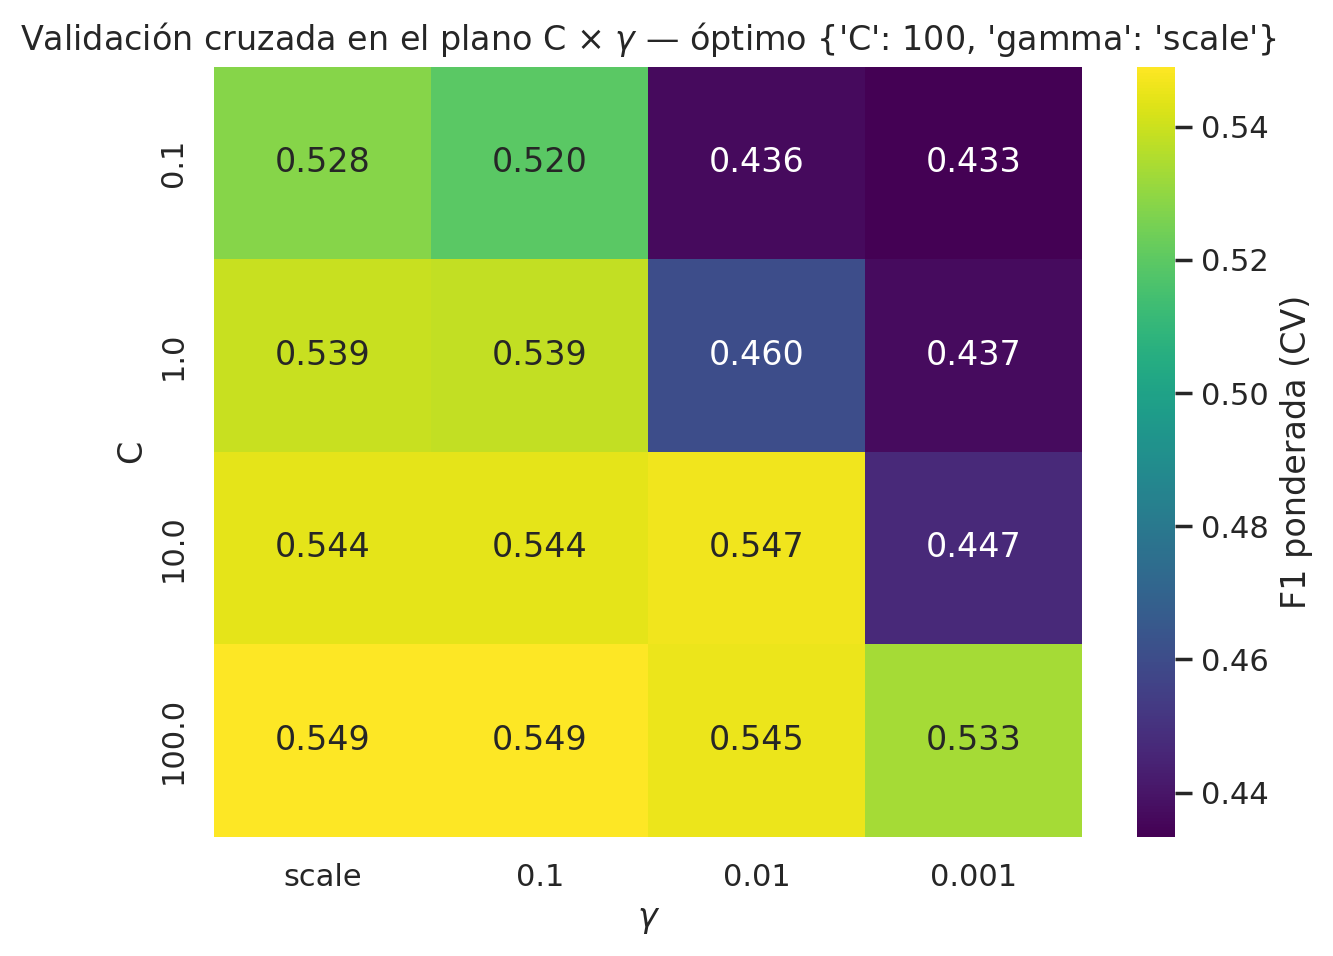

In [25]:
gs = GridSearchCV(SVC(kernel='rbf', random_state=123), pgrid, scoring='f1_weighted', cv=KFold(5))
gs.fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_, '| F1 ponderada CV:', round(gs.best_score_, 3))
modelo = gs.best_estimator_
cv_heatmap(gs)

In [26]:
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.62      0.49      0.54       915
           I       0.73      0.82      0.77       939
           M       0.57      0.61      0.59      1069

    accuracy                           0.64      2923
   macro avg       0.64      0.64      0.63      2923
weighted avg       0.63      0.64      0.63      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.45      0.38      0.41       392
           I       0.74      0.79      0.76       403
           M       0.48      0.52      0.50       459

    accuracy                           0.56      1254
   macro avg       0.56      0.56      0.56      1254
weighted avg       0.56      0.56      0.56      1254



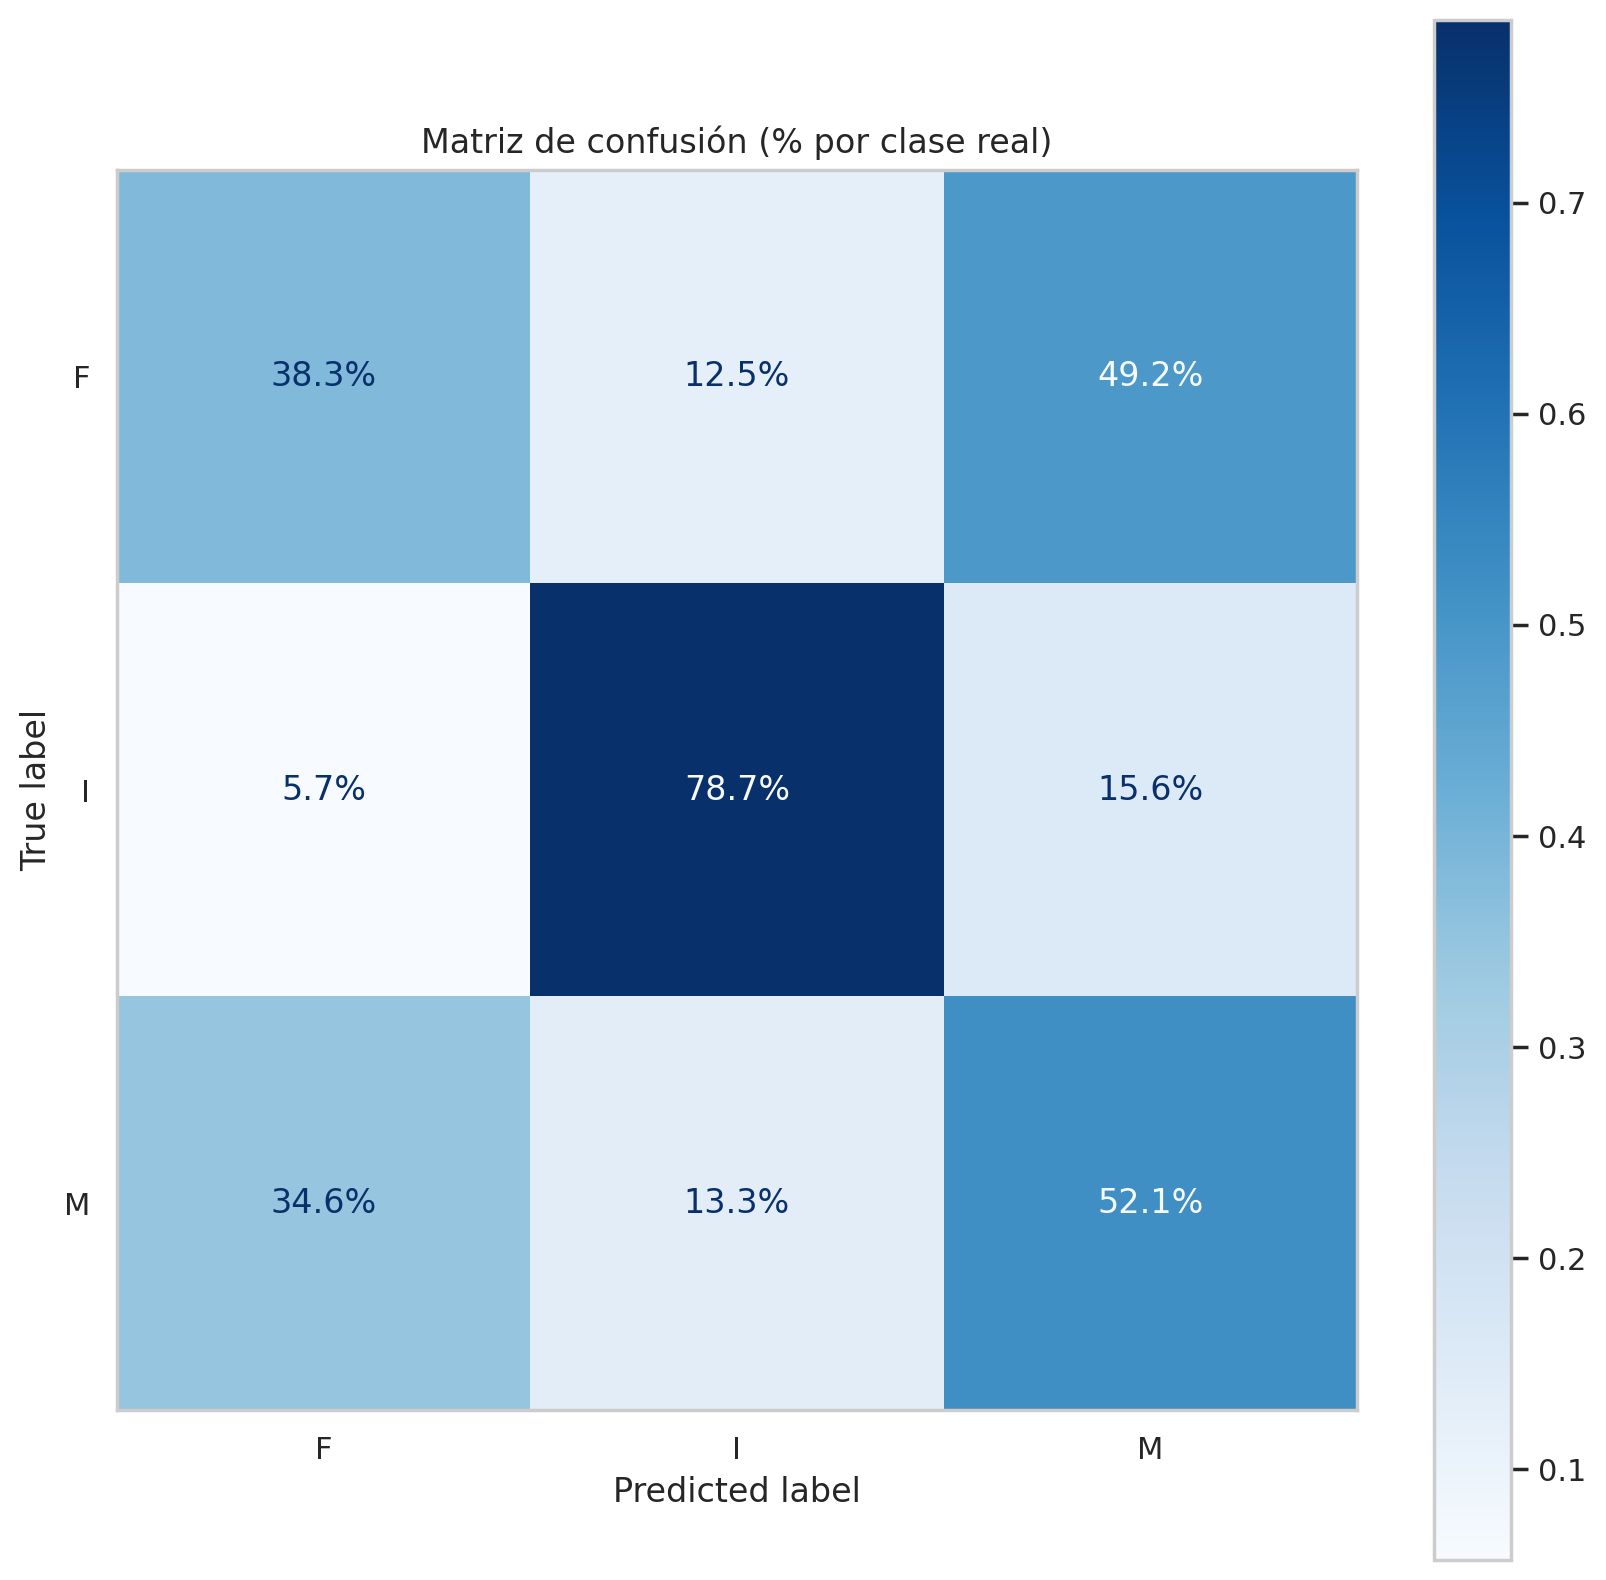

In [27]:
matriz_confusion(modelo, xtest, ytest);

In [28]:
val = validar_modelo(modelo, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.556 +/- 0.024


El RBF mejora **muy poco** sobre el lineal (~0.55 frente a ~0.54): **M y F siguen confundiéndose** porque sus medidas morfométricas son casi idénticas. Aquí el problema no es la forma de la frontera (lineal o curva), sino que **las predictoras no contienen la información** para distinguir machos de hembras. Ni siquiera un kernel flexible puede inventar una señal que no está en los datos.



# <font color="steelblue">4. Referencias</font>

* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 9). Springer.
* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 12).
* Hsu, Chang & Lin (2016). *A Practical Guide to Support Vector Classification*.
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Support Vector Machines*: https://scikit-learn.org/stable/modules/svm.html